In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import numba as nb
import matplotlib.pyplot as plt

import sys
sys.path.append('../src/')
import utils

import FSC as controller

In [3]:
import environments
import os
import pickle
import time as measure_time

In [4]:
from matplotlib.colors import ListedColormap, BoundaryNorm
import pandas as pd

In [5]:
def compute_shift_observables_from_trjs(trajectories, idx_start = -10, idx_end = 20):
    probs_correct_gen = np.zeros((len(trajectories), idx_end - idx_start))
    probs_switch_gen = np.zeros((len(trajectories), idx_end - idx_start))

    for idx_trj, gtrj in enumerate(trajectories):
        curr_states = np.array([trdict["better arm"] for trdict in gtrj["states"]])
        curr_acts = np.array([0 if act == "play arm 1" else 1 for act in gtrj["actions"]])
        curr_acts_switch = np.concatenate([np.array([0]), np.abs(np.diff(curr_acts))])
        switch_idxs = np.where(np.diff(curr_states) != 0)[0]
        switch_idxs = np.concatenate(([0], switch_idxs, [len(curr_states)]))

        probscorr = np.zeros((len(switch_idxs) - 2, idx_end - idx_start))
        probs_switch = np.zeros((len(switch_idxs) - 2, idx_end - idx_start))

        for i in range(1, len(switch_idxs) - 2):
            curr_idx = switch_idxs[i]
            iistart = curr_idx + idx_start
            if iistart < 0:
                iistart = 0

            iiend = curr_idx + idx_end
            if iiend > len(curr_states):
                iiend = len(curr_states)

            if curr_idx + idx_start > switch_idxs[i - 1] and curr_idx + idx_end <= switch_idxs[i + 1]:
                # enough points both to the left and right
                acts = curr_acts[iistart : iiend]
                targets = curr_states[iistart : iiend]
                pp = (acts == targets) * 1

                act_switches = curr_acts_switch[iistart : iiend]

            elif curr_idx + idx_start <= switch_idxs[i - 1] and curr_idx + idx_end <= switch_idxs[i + 1]:
                # not enough points on the left, enough on the right
                acts = curr_acts[switch_idxs[i - 1] : iiend]
                targets = curr_states[switch_idxs[i - 1]:iiend]
                pp = (acts == targets) * 1

                pp_nan = np.ones(switch_idxs[i - 1] - (curr_idx + idx_start)) * np.nan
                pp = np.concatenate([pp_nan, pp])

                act_switches = curr_acts_switch[switch_idxs[i - 1]:iiend]
                act_switches_nan = np.ones(switch_idxs[i - 1] - (curr_idx + idx_start)) * np.nan
                act_switches = np.concatenate([act_switches_nan, act_switches])

            elif curr_idx + idx_start > switch_idxs[i - 1] and curr_idx + idx_end > switch_idxs[i + 1]:
                # enough points on the left, not enough on the right
                acts = curr_acts[iistart : switch_idxs[i + 1]]
                targets = curr_states[iistart:switch_idxs[i + 1]]
                pp = (acts == targets) * 1

                pp_nan = np.ones((curr_idx + idx_end) - switch_idxs[i + 1]) * np.nan
                pp = np.concatenate([pp, pp_nan])

                act_switches = curr_acts_switch[iistart:switch_idxs[i + 1]]
                act_switches_nan = np.ones((curr_idx + idx_end) - switch_idxs[i + 1]) * np.nan
                act_switches = np.concatenate([act_switches, act_switches_nan])

            elif curr_idx + idx_start <= switch_idxs[i - 1] and curr_idx + idx_end > switch_idxs[i + 1]:
                # not enough points on the left, not enough on the right
                acts = curr_acts[switch_idxs[i - 1] : switch_idxs[i + 1]]
                targets = curr_states[switch_idxs[i - 1]:switch_idxs[i + 1]]
                pp = (acts == targets) * 1

                pp_nan_left = np.ones(switch_idxs[i - 1] - (curr_idx + idx_start)) * np.nan
                pp_nan_right = np.ones((curr_idx + idx_end) - switch_idxs[i + 1]) * np.nan
                pp = np.concatenate([pp_nan_left,
                                        pp,
                                        pp_nan_right])

                act_switches = curr_acts_switch[switch_idxs[i - 1]:switch_idxs[i + 1]]
                act_switches_nan_left = np.ones(switch_idxs[i - 1] - (curr_idx + idx_start)) * np.nan
                act_switches_nan_right = np.ones((curr_idx + idx_end) - switch_idxs[i + 1]) * np.nan
                act_switches = np.concatenate([act_switches_nan_left, act_switches, act_switches_nan_right])
            else:
                print(curr_idx + idx_start, curr_idx + idx_end, switch_idxs[i - 1], switch_idxs[i + 1])
                raise ValueError("Incompatible shapes")
            probscorr[i - 1] = pp
            probs_switch[i - 1] = act_switches

        probs_correct_gen[idx_trj] = np.nanmean(probscorr, axis=0)
        probs_switch_gen[idx_trj] = np.nanmean(probs_switch, axis=0)

    probs_correct_gen = np.nanmean(probs_correct_gen, axis=0)
    probs_switch_gen = np.nanmean(probs_switch_gen, axis=0)

    return probs_correct_gen, probs_switch_gen

In [8]:
probs_condition = '80-20' # P(high)-P(low)
train_percentage = 0.8

data_path = "../data/MouseBandits/"
data = pd.read_csv(data_path + "bandit_data.csv")
data = data.loc[data.Condition==probs_condition] # segment out task condition

In [9]:
theta = 0.8
eps = 0.02
env_params = (theta, eps)
env_params_dict = {"theta": env_params[0], "epsilon": env_params[1]}
env = environments.SymmetricTwoArmsBernoulliBandits.EnvironmentModel(env_params_dict)

# Experimental data

In [10]:
mouses = np.unique([s[:2] for s in np.unique(data["Session"])])

sessions_train = []
sessions_val = []

for idx, ms in enumerate(mouses):
    data_curr = np.unique(data["Session"][data["Session"].str.startswith(ms)])
    sessions_train.append(data_curr[ : int(len(data_curr) * train_percentage)])
    sessions_val.append(data_curr[int(len(data_curr) * train_percentage):])

In [11]:
print("There are", np.sum([len(s) for s in sessions_train]), "sessions in total used for training.")
print("There are", np.sum([len(s) for s in sessions_val]), "sessions in total used for validation.")

for idx, ms in enumerate(mouses):
    print("\t There are", len(sessions_train[idx]) + len(sessions_val[idx]), "sessions for mouse", ms + str("."), end=" ")
    print(f"Training is going to use {len(sessions_train[idx])} sessions, validation {len(sessions_val[idx])} sessions.")

There are 126 sessions in total used for training.
There are 33 sessions in total used for validation.
	 There are 29 sessions for mouse m1. Training is going to use 23 sessions, validation 6 sessions.
	 There are 30 sessions for mouse m2. Training is going to use 24 sessions, validation 6 sessions.
	 There are 30 sessions for mouse m3. Training is going to use 24 sessions, validation 6 sessions.
	 There are 26 sessions for mouse m4. Training is going to use 20 sessions, validation 6 sessions.
	 There are 19 sessions for mouse m5. Training is going to use 15 sessions, validation 4 sessions.
	 There are 25 sessions for mouse m6. Training is going to use 20 sessions, validation 5 sessions.


In [12]:
durations_train = []

idx_start = -10
idx_end = 20
shifts_time = np.arange(idx_start, idx_end)
probs_correct_data_train = np.zeros((len(mouses), idx_end - idx_start))
probs_switch_data_train = np.zeros((len(mouses), idx_end - idx_start))

for idx_mouse, ms in enumerate(mouses):
    durations_temp = []

    for idx_trial, trial in enumerate(sessions_train[idx_mouse]):
        data_session = data[data["Session"] == trial]
        durations_temp.append(len(data_session))

        switch_idxs = np.where(np.diff(data_session["Target"]) != 0)[0]
        switch_idxs = np.concatenate(([0], switch_idxs, [len(data_session)]))

        probscorr = np.zeros((len(switch_idxs) - 2, idx_end - idx_start))
        probs_switch = np.zeros((len(switch_idxs) - 2, idx_end - idx_start))

        for i in range(1, len(switch_idxs) - 2):
            curr_idx = switch_idxs[i]
            iistart = curr_idx + idx_start
            if iistart < 0:
                iistart = 0

            iiend = curr_idx + idx_end
            if iiend > len(data_session):
                iiend = len(data_session)

            if curr_idx + idx_start > switch_idxs[i - 1] and curr_idx + idx_end < switch_idxs[i + 1]:
                # enough points both to the left and right
                acts = np.array(data_session["Decision"].iloc[iistart : iiend])
                targets = np.array(data_session["Target"].iloc[iistart : iiend])
                pp = (acts == targets) * 1

                act_switches = np.array(data_session["Switch"].iloc[iistart : iiend])

            elif curr_idx + idx_start < switch_idxs[i - 1] and curr_idx + idx_end < switch_idxs[i + 1]:
                # not enough points on the left, enough on the right
                acts = np.array(data_session["Decision"].iloc[switch_idxs[i - 1]:iiend])
                targets = np.array(data_session["Target"].iloc[switch_idxs[i - 1]:iiend])
                pp = (acts == targets) * 1

                pp_nan = np.ones(switch_idxs[i - 1] - (curr_idx + idx_start)) * np.nan
                pp = np.concatenate([pp_nan, pp])

                act_switches = np.array(data_session["Switch"].iloc[switch_idxs[i - 1]:iiend])
                act_switches_nan = np.ones(switch_idxs[i - 1] - (curr_idx + idx_start)) * np.nan
                act_switches = np.concatenate([act_switches_nan, act_switches])

            elif curr_idx + idx_start > switch_idxs[i - 1] and curr_idx + idx_end > switch_idxs[i + 1]:
                # enough points on the left, not enough on the right
                acts = np.array(data_session["Decision"].iloc[iistart:switch_idxs[i + 1]])
                targets = np.array(data_session["Target"].iloc[iistart:switch_idxs[i + 1]])
                pp = (acts == targets) * 1

                pp_nan = np.ones((curr_idx + idx_end) - switch_idxs[i + 1]) * np.nan
                pp = np.concatenate([pp, pp_nan])

                act_switches = np.array(data_session["Switch"].iloc[iistart:switch_idxs[i + 1]])
                act_switches_nan = np.ones((curr_idx + idx_end) - switch_idxs[i + 1]) * np.nan
                act_switches = np.concatenate([act_switches, act_switches_nan])

            elif curr_idx + idx_start < switch_idxs[i - 1] and curr_idx + idx_end > switch_idxs[i + 1]:
                # not enough points on the left, not enough on the right
                acts = np.array(data_session["Decision"].iloc[switch_idxs[i - 1]:switch_idxs[i + 1]])
                targets = np.array(data_session["Target"].iloc[switch_idxs[i - 1]:switch_idxs[i + 1]])
                pp = (acts == targets) * 1

                pp_nan_left = np.ones(switch_idxs[i - 1] - (curr_idx + idx_start)) * np.nan
                pp_nan_right = np.ones((curr_idx + idx_end) - switch_idxs[i + 1]) * np.nan
                pp = np.concatenate([pp_nan_left,
                                     pp,
                                     pp_nan_right])

                act_switches = np.array(data_session["Switch"].iloc[switch_idxs[i - 1]:switch_idxs[i + 1]])
                act_switches_nan_left = np.ones(switch_idxs[i - 1] - (curr_idx + idx_start)) * np.nan
                act_switches_nan_right = np.ones((curr_idx + idx_end) - switch_idxs[i + 1]) * np.nan
                act_switches = np.concatenate([act_switches_nan_left, act_switches, act_switches_nan_right])
            
            probscorr[i - 1] = pp
            probs_switch[i - 1] = act_switches

        probs_correct_data_train[idx_mouse] += np.nanmean(probscorr, axis=0)
        probs_switch_data_train[idx_mouse] += np.nanmean(probs_switch, axis=0)

    probs_correct_data_train[idx_mouse] /= len(sessions_train[idx_mouse])
    probs_switch_data_train[idx_mouse] /= len(sessions_train[idx_mouse])
    durations_train.append(durations_temp)

In [13]:
durations_val = []

idx_start = -10
idx_end = 20
shifts_time = np.arange(idx_start, idx_end)
probs_correct_data_val = np.zeros((len(mouses), idx_end - idx_start))
probs_switch_data_val = np.zeros((len(mouses), idx_end - idx_start))

for idx_mouse, ms in enumerate(mouses):
    durations_temp = []

    for idx_trial, trial in enumerate(sessions_val[idx_mouse]):
        data_session = data[data["Session"] == trial]
        durations_temp.append(len(data_session))

        switch_idxs = np.where(np.diff(data_session["Target"]) != 0)[0]
        switch_idxs = np.concatenate(([0], switch_idxs, [len(data_session)]))

        probscorr = np.zeros((len(switch_idxs) - 2, idx_end - idx_start))
        probs_switch = np.zeros((len(switch_idxs) - 2, idx_end - idx_start))

        for i in range(1, len(switch_idxs) - 2):
            curr_idx = switch_idxs[i]
            iistart = curr_idx + idx_start
            if iistart < 0:
                iistart = 0

            iiend = curr_idx + idx_end
            if iiend > len(data_session):
                iiend = len(data_session)

            if curr_idx + idx_start > switch_idxs[i - 1] and curr_idx + idx_end < switch_idxs[i + 1]:
                # enough points both to the left and right
                acts = np.array(data_session["Decision"].iloc[iistart : iiend])
                targets = np.array(data_session["Target"].iloc[iistart : iiend])
                pp = (acts == targets) * 1

                act_switches = np.array(data_session["Switch"].iloc[iistart : iiend])

            elif curr_idx + idx_start < switch_idxs[i - 1] and curr_idx + idx_end < switch_idxs[i + 1]:
                # not enough points on the left, enough on the right
                acts = np.array(data_session["Decision"].iloc[switch_idxs[i - 1]:iiend])
                targets = np.array(data_session["Target"].iloc[switch_idxs[i - 1]:iiend])
                pp = (acts == targets) * 1

                pp_nan = np.ones(switch_idxs[i - 1] - (curr_idx + idx_start)) * np.nan
                pp = np.concatenate([pp_nan, pp])

                act_switches = np.array(data_session["Switch"].iloc[switch_idxs[i - 1]:iiend])
                act_switches_nan = np.ones(switch_idxs[i - 1] - (curr_idx + idx_start)) * np.nan
                act_switches = np.concatenate([act_switches_nan, act_switches])

            elif curr_idx + idx_start > switch_idxs[i - 1] and curr_idx + idx_end > switch_idxs[i + 1]:
                # enough points on the left, not enough on the right
                acts = np.array(data_session["Decision"].iloc[iistart:switch_idxs[i + 1]])
                targets = np.array(data_session["Target"].iloc[iistart:switch_idxs[i + 1]])
                pp = (acts == targets) * 1

                pp_nan = np.ones((curr_idx + idx_end) - switch_idxs[i + 1]) * np.nan
                pp = np.concatenate([pp, pp_nan])

                act_switches = np.array(data_session["Switch"].iloc[iistart:switch_idxs[i + 1]])
                act_switches_nan = np.ones((curr_idx + idx_end) - switch_idxs[i + 1]) * np.nan
                act_switches = np.concatenate([act_switches, act_switches_nan])

            elif curr_idx + idx_start < switch_idxs[i - 1] and curr_idx + idx_end > switch_idxs[i + 1]:
                # not enough points on the left, not enough on the right
                acts = np.array(data_session["Decision"].iloc[switch_idxs[i - 1]:switch_idxs[i + 1]])
                targets = np.array(data_session["Target"].iloc[switch_idxs[i - 1]:switch_idxs[i + 1]])
                pp = (acts == targets) * 1

                pp_nan_left = np.ones(switch_idxs[i - 1] - (curr_idx + idx_start)) * np.nan
                pp_nan_right = np.ones((curr_idx + idx_end) - switch_idxs[i + 1]) * np.nan
                pp = np.concatenate([pp_nan_left,
                                     pp,
                                     pp_nan_right])

                act_switches = np.array(data_session["Switch"].iloc[switch_idxs[i - 1]:switch_idxs[i + 1]])
                act_switches_nan_left = np.ones(switch_idxs[i - 1] - (curr_idx + idx_start)) * np.nan
                act_switches_nan_right = np.ones((curr_idx + idx_end) - switch_idxs[i + 1]) * np.nan
                act_switches = np.concatenate([act_switches_nan_left, act_switches, act_switches_nan_right])
            
            probscorr[i - 1] = pp
            probs_switch[i - 1] = act_switches

        probs_correct_data_val[idx_mouse] += np.nanmean(probscorr, axis=0)
        probs_switch_data_val[idx_mouse] += np.nanmean(probs_switch, axis=0)

    probs_correct_data_val[idx_mouse] /= len(sessions_val[idx_mouse])
    probs_switch_data_val[idx_mouse] /= len(sessions_val[idx_mouse])
    durations_val.append(durations_temp)

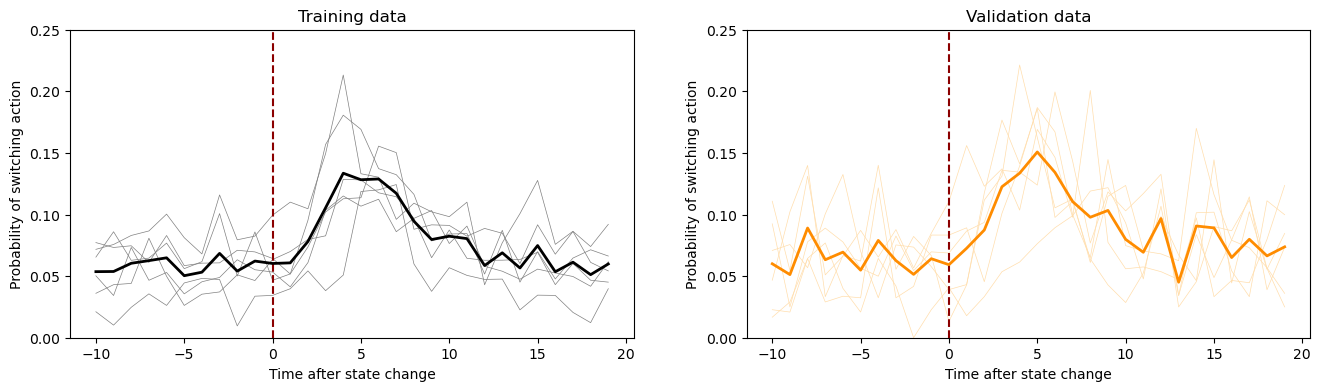

In [14]:
fig, axs = plt.subplots(ncols = 2, nrows = 1, figsize = (16, 4))
axs[0].plot(shifts_time, probs_switch_data_train.mean(axis = 0), c = "k", lw = 2, label = "Training data")
axs[1].plot(shifts_time, probs_switch_data_val.mean(axis = 0), c = "darkorange", lw = 2, label = "Validation data")

for psd in probs_switch_data_train:
    axs[0].plot(shifts_time, psd, c = "gray", lw = 0.5, zorder = -1)
for psd in probs_switch_data_val:
    axs[1].plot(shifts_time, psd, c = "navajowhite", lw = 0.5, zorder = -1)

for ax in axs:
    ax.set_xlabel("Time after state change")
    ax.set_ylabel("Probability of switching action")
    ax.axvline(0, ls = "--", c = "darkred", zorder = -1)

axs[0].set_title("Training data")
axs[1].set_title("Validation data")
axs[0].set_ylim(0, 0.25)
axs[1].set_ylim(0, 0.25)
plt.show()

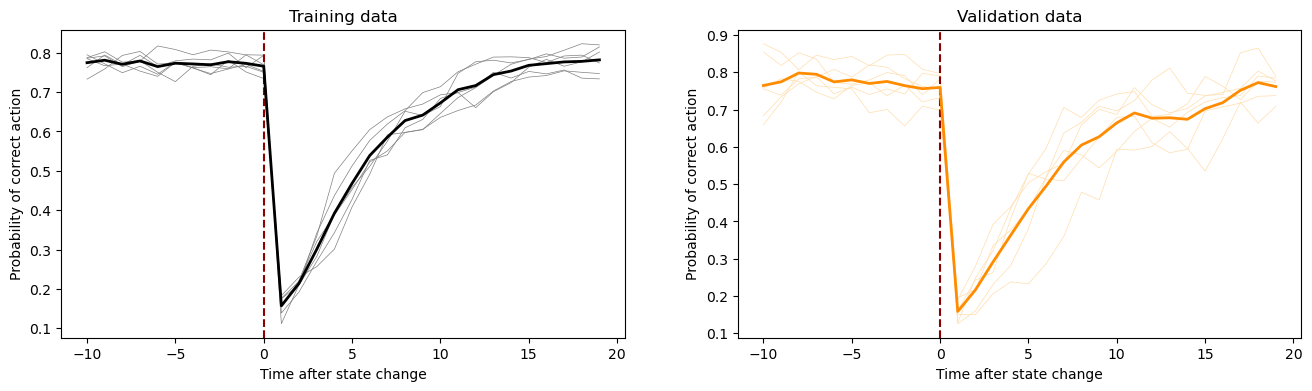

In [15]:
fig, axs = plt.subplots(ncols = 2, nrows = 1, figsize = (16, 4))
axs[0].plot(shifts_time, probs_correct_data_train.mean(axis = 0), c = "k", lw = 2)
axs[1].plot(shifts_time, probs_correct_data_val.mean(axis = 0), c = "darkorange", lw = 2)

for psd in probs_correct_data_train:
    axs[0].plot(shifts_time, psd, c = "gray", lw = 0.5, zorder = -1)

for psd in probs_correct_data_val:
    axs[1].plot(shifts_time, psd, c = "navajowhite", lw = 0.5, zorder = -1)

for ax in axs:
    ax.set_xlabel("Time after state change")
    ax.set_ylabel("Probability of correct action")
    ax.axvline(0, ls = "--", c = "darkred", zorder = -1)

axs[0].set_title("Training data")
axs[1].set_title("Validation data")

plt.show()

In [16]:
idx_mouse = 0
idx_trial = 0
data_session = data[data["Session"] == sessions_train[idx_mouse][idx_trial]]
data_session[:30]

,Trial,blockTrial,Decision,Switch,Reward,Condition,Target,blockLength,Session,Mouse
110647,11.0,11.0,1.0,1.0,1.0,80-20,0.0,23.0,m1_16,m1
110648,12.0,12.0,1.0,0.0,1.0,80-20,0.0,23.0,m1_16,m1
110649,13.0,13.0,1.0,0.0,1.0,80-20,0.0,23.0,m1_16,m1
110650,14.0,14.0,0.0,1.0,1.0,80-20,0.0,23.0,m1_16,m1
110651,15.0,15.0,0.0,0.0,1.0,80-20,0.0,23.0,m1_16,m1
110652,16.0,16.0,0.0,0.0,1.0,80-20,0.0,23.0,m1_16,m1
110653,17.0,17.0,0.0,0.0,1.0,80-20,0.0,23.0,m1_16,m1
110654,18.0,18.0,0.0,0.0,0.0,80-20,0.0,23.0,m1_16,m1
110655,19.0,19.0,0.0,0.0,1.0,80-20,0.0,23.0,m1_16,m1
110656,20.0,20.0,0.0,0.0,1.0,80-20,0.0,23.0,m1_16,m1


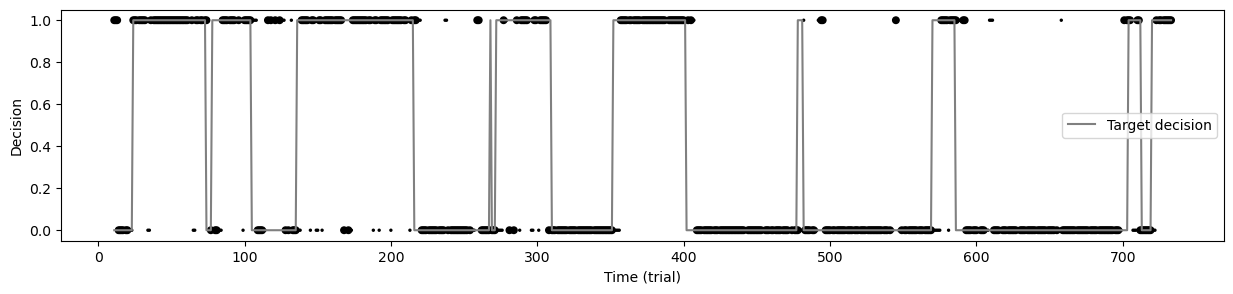

In [17]:
fig, ax = plt.subplots(figsize = (15, 3))
ax.scatter(data_session["Trial"], data_session["Decision"], s = (data_session["Reward"] + 0.1)* 20, c = 'k')
ax.plot(data_session["Trial"], data_session["Target"], c = 'gray', label = "Target decision")
ax.set_xlabel("Time (trial)")
ax.set_ylabel("Decision")
ax.legend()
plt.show()

In [18]:
trajectories_data_train = []
actions_data_train = []
observations_data_train = []
rewards_data_train = []
states_data_train = []

trajectories_data_val = []
actions_data_val = []
observations_data_val = []
rewards_data_val = []
states_data_val = []

for idx_mouse, ms in enumerate(mouses):

    for idx_trial, s in enumerate(sessions_train[idx_mouse]):
        data_session = data[data["Session"] == sessions_train[idx_mouse][idx_trial]]
        actions = np.array(data_session["Decision"])
        # substitute "0" with right and "1" with left
        actions = np.where(actions == 0, "play arm 1", "play arm 2")

        rewards = np.array(data_session["Reward"])
        # substitute "0" with lose and "1" with win
        observations = rewards.copy()
        observations = np.where(observations == 0, "lose", "win")

        states = np.array(data_session["Target"])

        dict_traj = {}
        dict_traj["actions"] = actions
        dict_traj["observations"] = observations

        trajectories_data_train.append(dict_traj)

        actions_data_train.append(actions)
        observations_data_train.append(observations)
        states_data_train.append(states)
        rewards_data_train.append(rewards)

    for idx_trial, s in enumerate(sessions_val[idx_mouse]):
        data_session = data[data["Session"] == sessions_val[idx_mouse][idx_trial]]
        actions = np.array(data_session["Decision"])
        # substitute "0" with right and "1" with left
        actions = np.where(actions == 0, "play arm 1", "play arm 2")

        rewards = np.array(data_session["Reward"])
        # substitute "0" with lose and "1" with win
        observations = rewards.copy()
        observations = np.where(observations == 0, "lose", "win")

        states = np.array(data_session["Target"])

        dict_traj = {}
        dict_traj["actions"] = actions
        dict_traj["observations"] = observations

        trajectories_data_val.append(dict_traj)

        actions_data_val.append(actions)
        observations_data_val.append(observations)
        states_data_val.append(states)
        rewards_data_val.append(rewards)

# Aggregated data analysis

In [19]:
StatesSpace = np.array(["arm 1 is better", "arm 2 is better"])
initial_states_data_train_dict = [{"better arm": int(s[0])} for s in states_data_train]
initial_states_data_val_dict = [{"better arm": int(s[0])} for s in states_data_val]

initial_states_data_dict = initial_states_data_train_dict + initial_states_data_val_dict

In [20]:
ActSpace = np.unique(np.concatenate(actions_data_train))
ObsSpace = np.unique(np.concatenate(observations_data_train))

A = len(ActSpace)
Y = len(ObsSpace)

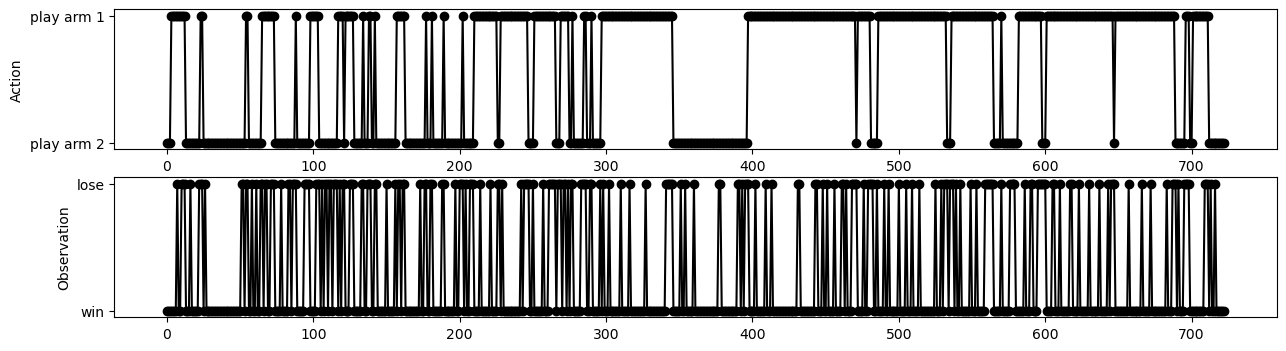

In [21]:
idx_trj = 0
fig, axs = plt.subplots(2, 1, figsize = (15, 4))

axs[0].plot(trajectories_data_train[idx_trj]["actions"], '-o', c = 'k')
axs[0].set_ylabel("Action")
axs[0].set_yticks(ActSpace)

axs[1].plot(trajectories_data_train[idx_trj]["observations"], '-o', c = 'k')
axs[1].set_ylabel("Observation")
axs[1].set_yticks(ObsSpace)

plt.show()

In [38]:
path_name = data_path + "80-20_train0.8/"
files_in_path = os.listdir(path_name)
FSC_params = [f for f in files_in_path if f.startswith("FSC") ]

M_array = np.arange(2, 10, 1)
FSC_list_M = []
MemSpaces_list = []
best_restart_idxs= []

for M in M_array:
    tic = measure_time.time()
    MemSpace = np.array(["mem " + str(num) for num in range(M)])
    MemSpaces_list.append(MemSpace)

    FSC_temp_list = []
    
    print("Loading FSC with M =", M)
    FSC_params_M = [f for f in FSC_params if f"M{M}_" in f]

    for filename in FSC_params_M:
        with open(os.path.join(path_name, filename), "rb") as f:
            print("\t Loading", filename)
            FSC_params_curr = pickle.load(f)

            FSC_curr = controller.FSC(M = M, A = A, Y = Y,
                                        mode = "generation",
                                        policy_model = "softmax",
                                        policy_params = {"theta": FSC_params_curr["theta"], "zeta": FSC_params_curr["zeta"]},
                                        psi = FSC_params_curr["psi"],
                                        ActSpace = ActSpace, MemSpace = MemSpace,
                                        ObsSpace = ObsSpace)
            
            FSC_curr.best_loss = FSC_curr.compute_loss(trajectories_data_val)
            FSC_curr.losses_epochs = {"train": FSC_params_curr["training_loss"]}
            print("\t Recomputed loss on validation data:", FSC_curr.best_loss)


        if type(FSC_curr) is list:
            for FSC in FSC_curr:
                FSC_temp_list.append(FSC)
        else:
            FSC_temp_list.append(FSC_curr)

    best_restart_idx = np.argmin([FSC.best_loss for FSC in FSC_temp_list])
    best_restart_idxs.append(best_restart_idx)
    FSC_list_M.append(FSC_temp_list)
    toc = measure_time.time()

    print("FSC with M =", M, "completed in", round(toc - tic, 2), "seconds.")
    print("Best loss:", FSC_temp_list[best_restart_idx].best_loss)
    print("\n")

Loading FSC with M = 2
	 Loading FSC_discrete_params_M2_A2_Y2_trained_loss144.223414_traintest0.8_restart18.pkl
	 Recomputed loss on validation data: 149.32069339054303
	 Loading FSC_discrete_params_M2_A2_Y2_trained_loss144.223414_traintest0.8_restart30.pkl
	 Recomputed loss on validation data: 149.3206875726129
	 Loading FSC_discrete_params_M2_A2_Y2_trained_loss144.223414_traintest0.8_restart24.pkl
	 Recomputed loss on validation data: 149.32069383750496
	 Loading FSC_discrete_params_M2_A2_Y2_trained_loss144.223414_traintest0.8_restart25.pkl
	 Recomputed loss on validation data: 149.32069373696555
	 Loading FSC_discrete_params_M2_A2_Y2_trained_loss144.223414_traintest0.8_restart31.pkl
	 Recomputed loss on validation data: 149.320692412781
	 Loading FSC_discrete_params_M2_A2_Y2_trained_loss144.223414_traintest0.8_restart19.pkl
	 Recomputed loss on validation data: 149.32069346913474
	 Loading FSC_discrete_params_M2_A2_Y2_trained_loss144.223414_traintest0.8_restart27.pkl
	 Recomputed lo

There are 25 FSCs with M = 2
There are 25 FSCs with M = 3
There are 25 FSCs with M = 4
There are 25 FSCs with M = 5
There are 25 FSCs with M = 6
There are 25 FSCs with M = 7
There are 25 FSCs with M = 8
There are 25 FSCs with M = 9


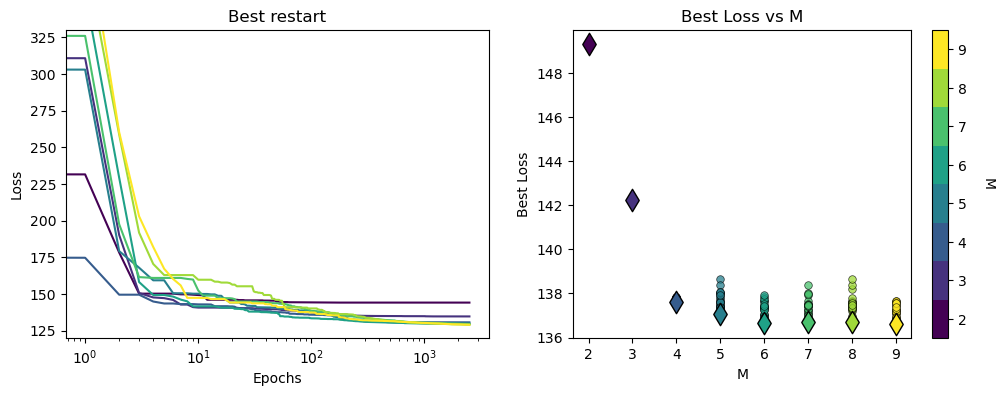

In [39]:
fig, axs = plt.subplots(1, 2, figsize=(12, 4))
#axs[0].set_yscale('log')
axs[0].set_xscale('log')
axs[0].set_xlabel('Epochs')
axs[0].set_ylabel('Loss')
axs[0].set_title('Best restart')
axs[1].set_xlabel('M')
axs[1].set_ylabel('Best Loss')
axs[1].set_title('Best Loss vs M')

colors = plt.get_cmap("viridis")(np.linspace(0, 1, len(FSC_list_M)))

for idx, FSC_list in enumerate(FSC_list_M):
    print("There are", len(FSC_list), "FSCs with M =", M_array[idx])
    FSC_curr_best = FSC_list[best_restart_idxs[idx]]
    axs[0].plot(FSC_curr_best.losses_epochs["train"], label="M = " + str(FSC_curr_best.M), color=colors[idx])

    for i in range(len(FSC_list)):
        FSC_curr = FSC_list[i]
        axs[1].scatter(FSC_curr.M, FSC_curr.best_loss, color=colors[idx], s=30, edgecolor='k', lw = 0.5, alpha=0.75)

    axs[1].scatter(FSC_curr_best.M, FSC_curr_best.best_loss, color=colors[idx],
                   marker='d',
                   s=130, edgecolor='k', lw = 1., label="Best M = " + str(FSC_curr_best.M))

cmap = plt.get_cmap("viridis", len(FSC_list_M))
norm = BoundaryNorm(np.arange(len(FSC_list_M)+1)-0.5, len(FSC_list_M))

# Create a ScalarMappable and colorbar
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
cbar = plt.colorbar(sm, ax=axs[1], orientation='vertical', ticks=np.arange(len(FSC_list_M)))
cbar.set_label('M', rotation=270, labelpad=20)
cbar.set_ticks(np.arange(len(FSC_list_M)))
cbar.set_ticklabels(M_array)
cbar.ax.yaxis.set_minor_locator(plt.NullLocator())

#axs[1].set_yscale('log')
axs[0].set_ylim(120, 330)
plt.show()

In [40]:
best_losses_M_list = []
best_FSC_M_list = []
for idx, FSC_list in enumerate(FSC_list_M):
    FSC_curr_best = FSC_list[best_restart_idxs[idx]]
    best_losses_M_list.append(FSC_curr_best.best_loss)
    best_FSC_M_list.append(FSC_curr_best)
    print("Best loss for M = ", FSC_curr_best.M, " is ", FSC_curr_best.best_loss)

Best loss for M =  2  is  149.32064969273227
Best loss for M =  3  is  142.22621171381041
Best loss for M =  4  is  137.60697024028286
Best loss for M =  5  is  137.04984817253217
Best loss for M =  6  is  136.6628336305462
Best loss for M =  7  is  136.69659008004942
Best loss for M =  8  is  136.7151229395883
Best loss for M =  9  is  136.60922965358014


In [41]:
all_losses_epochs_val = []
for idx, FSC_list in enumerate(FSC_list_M):
    FSC_curr_best = FSC_list[best_restart_idxs[idx]]
    all_losses_epochs_val.append(FSC_curr_best.losses_epochs["train"])

In [42]:
all_losses = []

for idx_M, FSC_list in enumerate(FSC_list_M):
    curr_losses = np.zeros(len(FSC_list))
    for idx_restart, FSC in enumerate(FSC_list):
        curr_losses[idx_restart] = FSC.best_loss
        
    all_losses.append(curr_losses)

# Analysis for M = 2

In [33]:
idx_M2 = 0
FSC_M2 = best_FSC_M_list[idx_M2]
MemSpace_M2 = MemSpaces_list[idx_M2]

print("Best loss for M =", FSC_M2.M, "is", FSC_M2.best_loss)

FSC_M2.set_mode("generation")
generated_trajectories = FSC_M2.generate_trajectories(environment_model = env,
                                                        NSteps = 200,
                                                        NTraj = len(initial_states_data_dict),
                                                        initial_states = initial_states_data_dict,
                                                        obs_from_act = True)

generated_rewards = 1 * (np.array([trj["observations"] for trj in generated_trajectories]) == "win")

Best loss for M = 2 is 149.31988375294273


/var/folders/tq/vdh27z_571gbg17w072s1p7h0000gn/T/ipykernel_58659/55061930.py:30: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axs[1,0].legend()


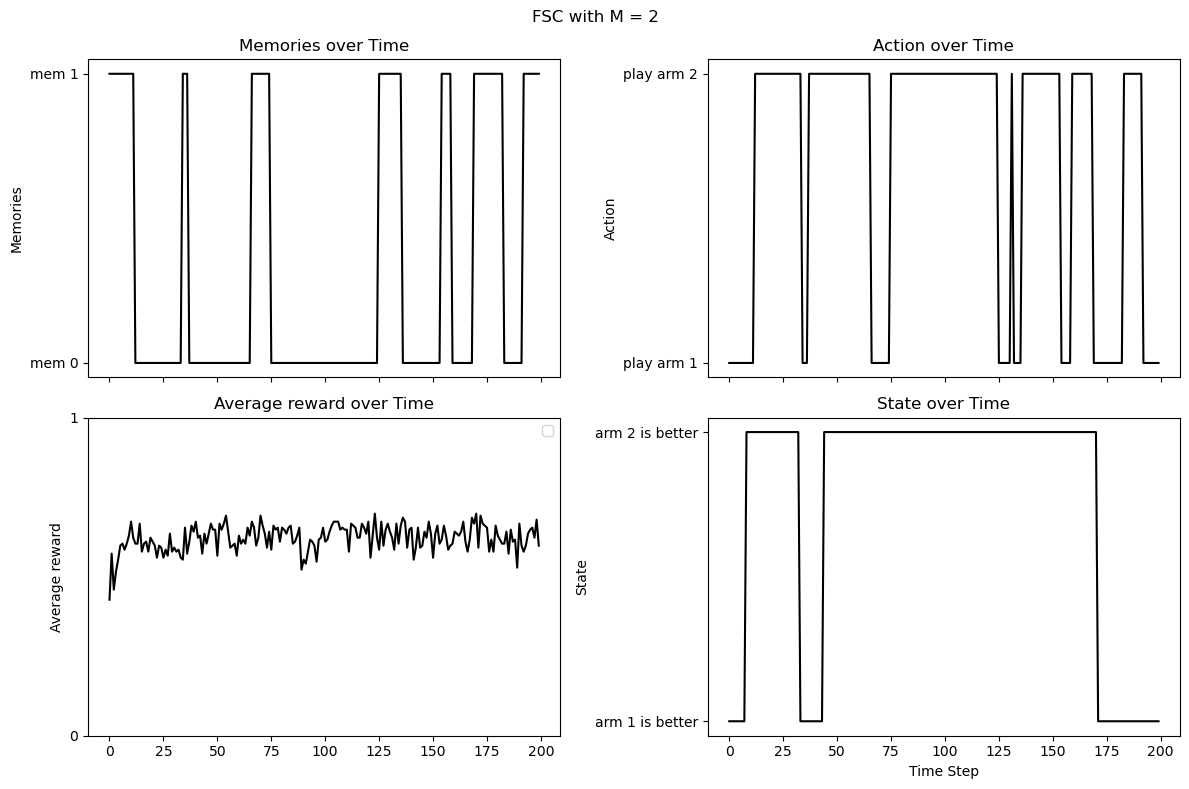

In [34]:
fig, axs = plt.subplots(2, 2, figsize=(12, 8), sharex=True)

fig.suptitle('FSC with M = ' + str(FSC_M2.M))

idx_traj = 0
trj = generated_trajectories[idx_traj]

act_numeric = [0 if act == "play arm 1" else 1 for act in trj["actions"]]
state_numeric = [state["better arm"] for state in trj["states"]]
# Map memory labels to indices according to MemSpaces
mem_label_to_idx = {mem: i for i, mem in enumerate(MemSpace_M2)}
mem_numeric = [mem_label_to_idx[m] for m in trj["memories"]]
axs[0, 0].plot(mem_numeric, alpha=1, color='k')
axs[0, 1].plot(act_numeric, alpha=1, color='k')

axs[1, 1].plot(state_numeric, alpha=1, color='k')

axs[0, 0].set_ylabel('Memories')
axs[0, 0].set_title('Memories over Time')
axs[0, 0].set_yticks(np.arange(len(MemSpace_M2)), MemSpace_M2)

axs[0, 1].set_ylabel('Action')
axs[0, 1].set_title('Action over Time')
axs[0, 1].set_yticks([0, 1], ActSpace)

axs[1, 0].plot(np.array(generated_rewards).mean(axis=0), alpha=1, color='k')
axs[1, 0].set_ylabel('Average reward')
axs[1, 0].set_title('Average reward over Time')
axs[1, 0].set_yticks([0, 1])
axs[1,0].legend()

axs[1, 1].set_ylabel('State')
axs[1, 1].set_title('State over Time')
axs[1, 1].set_xlabel('Time Step')
axs[1, 1].set_yticks([0, 1], StatesSpace)

plt.tight_layout()
plt.show()

In [35]:
idx_trj_st1 = 20
idx_trj_st2 = 0

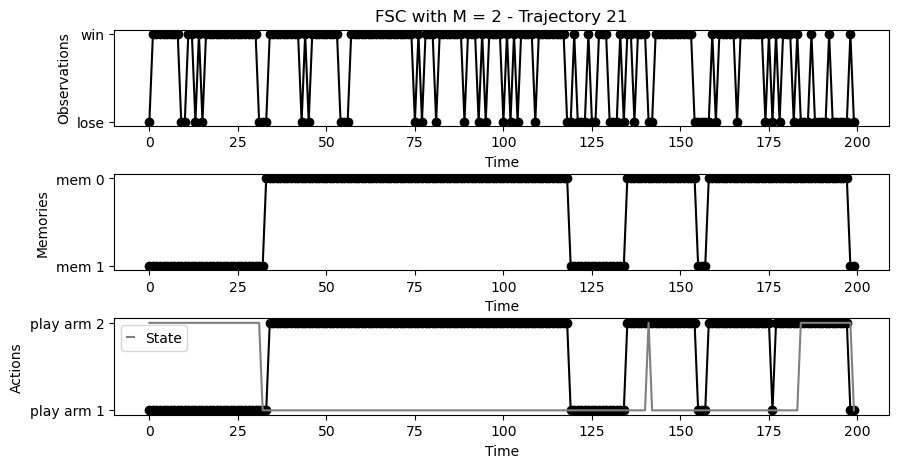

In [36]:
trj = generated_trajectories[idx_trj_st1]
fig, ax = FSC_M2.generator.plot_trajectory(trj)
ax[0].set_title('FSC with M = ' + str(FSC_M2.M) + ' - Trajectory ' + str(idx_trj_st1 + 1))
ax[2].plot([1 - t["better arm"] for t in trj["states"]], c = "gray", label = "State", lw = 1.5)

ax[2].legend(handlelength = 0.5)
plt.show()

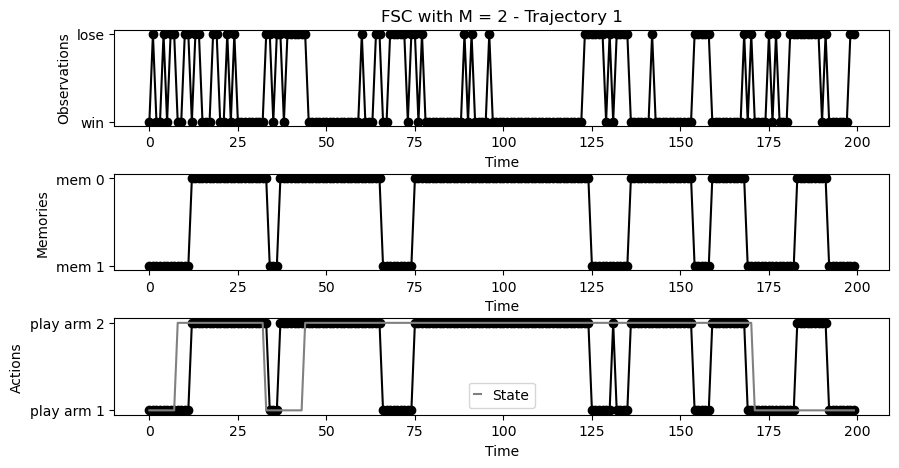

In [37]:
trj = generated_trajectories[idx_trj_st2]
fig, ax = FSC_M2.generator.plot_trajectory(trj)
ax[0].set_title('FSC with M = ' + str(FSC_M2.M) + ' - Trajectory ' + str(idx_trj_st2 + 1))
ax[2].plot([t["better arm"] for t in trj["states"]], c = "gray", label = "State", lw = 1.5)

ax[2].legend(handlelength = 0.5)
plt.show()

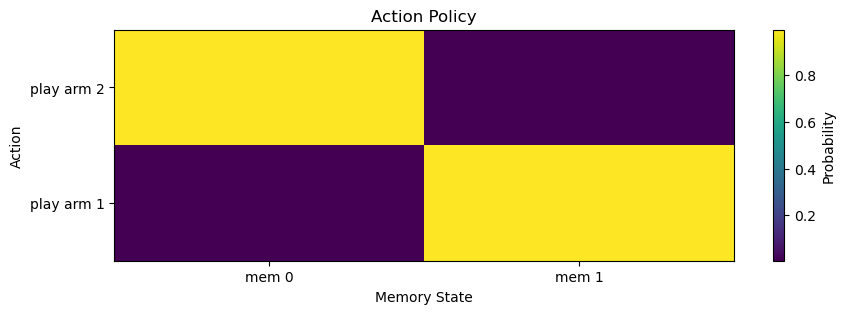

In [38]:
fig, ax = plt.subplots(figsize=(10, 3))
c = ax.pcolormesh(MemSpace_M2, ActSpace, FSC_M2.get_action_policy().T)
ax.set_xlabel('Memory State')
ax.set_ylabel('Action')
ax.set_title('Action Policy')
fig.colorbar(c, ax=ax, label='Probability', orientation='vertical')
plt.show()

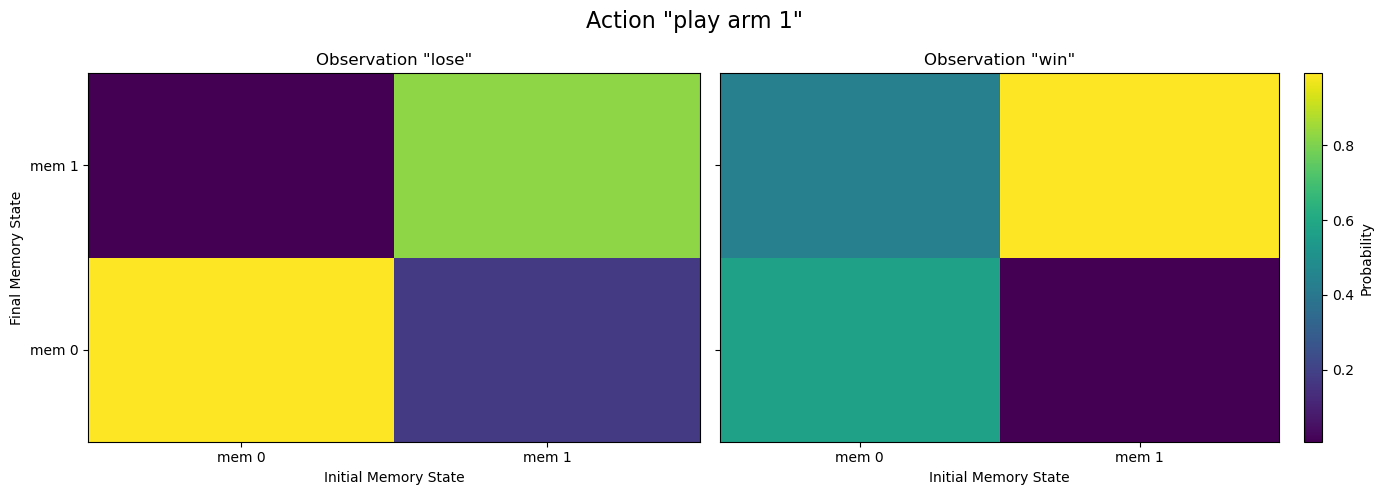

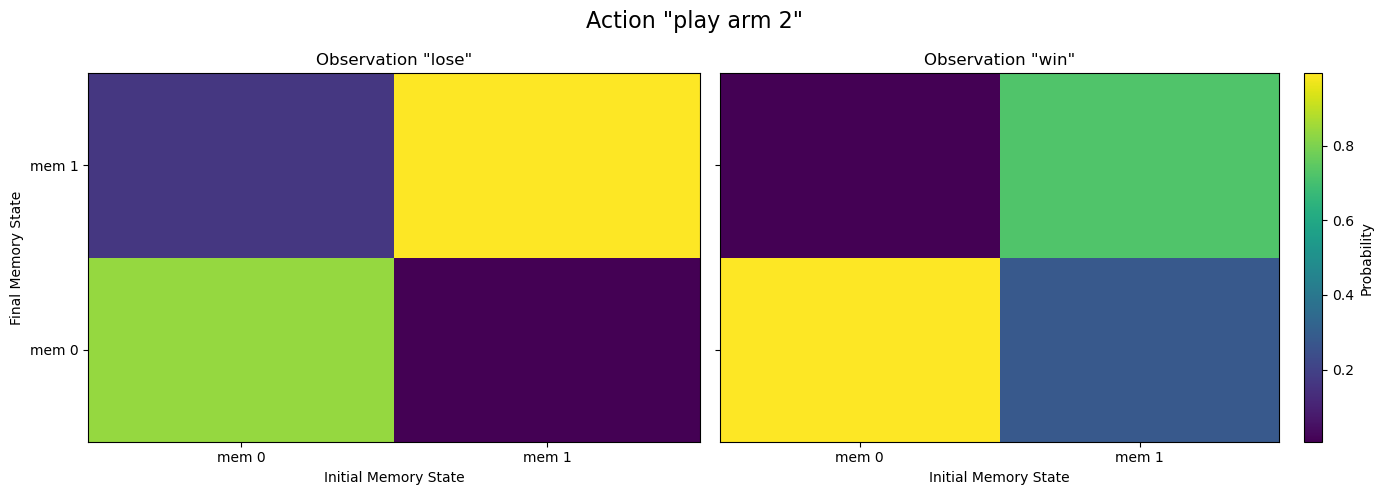

In [39]:
for idx_act in range(len(ActSpace)):
    fig, axs = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
    for idx_obs in range(len(ObsSpace)):
        c = axs[idx_obs].pcolormesh(
            MemSpace_M2,
            MemSpace_M2,
            FSC_M2.get_memory_transitions()[idx_obs][idx_act].T
        )
        axs[idx_obs].set_xlabel('Initial Memory State')
        axs[idx_obs].set_title(f'Observation "{ObsSpace[idx_obs]}"')
        fig.suptitle(f'Action "{ActSpace[idx_act]}"', fontsize=16)
        if idx_obs == 0:
            axs[idx_obs].set_ylabel('Final Memory State')
        if idx_obs == 1:
            fig.colorbar(c, ax=axs[idx_obs], label='Probability', orientation='vertical', fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.show()

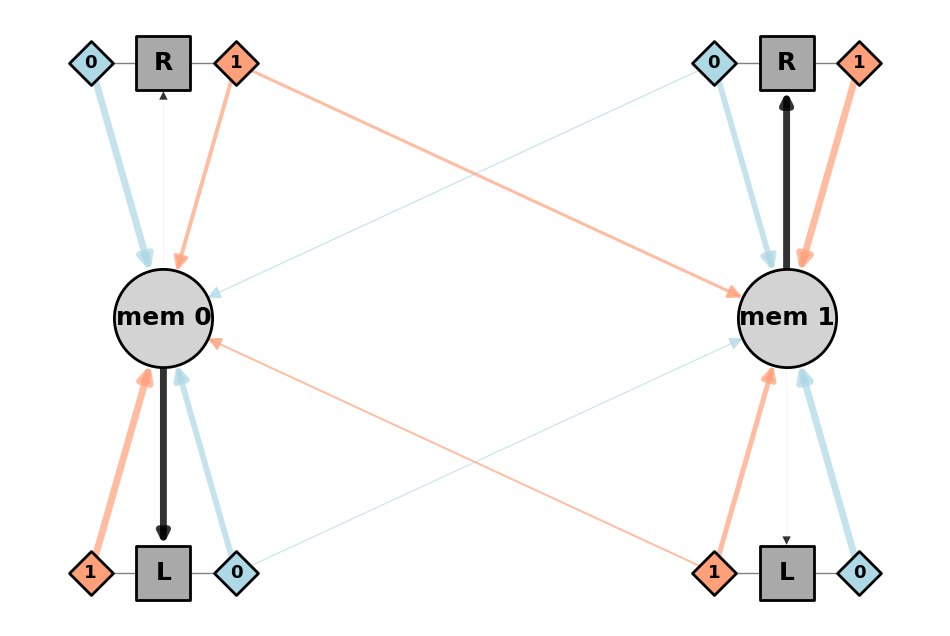

In [40]:
chain_ordering_M2 = utils.get_optimized_memory_order(
    FSC_M2.get_action_policy(),
    FSC_M2.get_memory_transitions(),
    action_threshold=0.6,
    fade_no_incoming=True,
    min_weight_threshold=0.01,
    reverse_left_part = False,
    reverse_right_part = True
)

ax = FSC_M2.plot_FSC(observation_node_colors=['lightblue', 'lightsalmon'], memory_ordering = chain_ordering_M2,
                     action_names=['R', 'L'], observation_names=['0', '1'],
                     th_action_probs=1e-3, th_mem_transitions=1e-3)
plt.show()

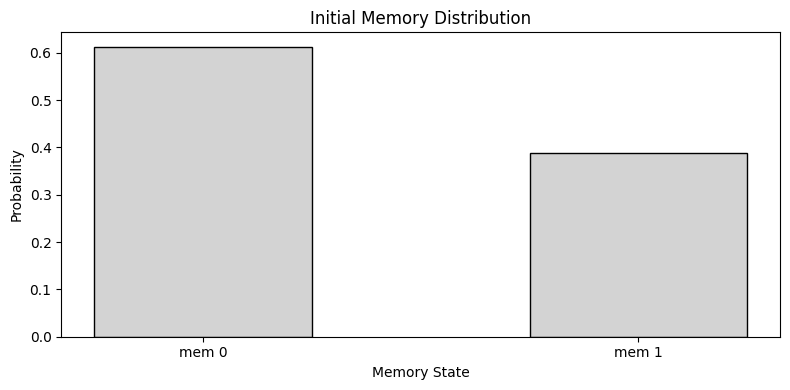

In [79]:
rho = FSC_M2.rho

# rho is the initial distribution of memory states, make an histogram of it
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(np.arange(len(rho)), rho, color='lightgray', edgecolor='k', width=0.5)
ax.set_xlabel('Memory State')
ax.set_ylabel('Probability')
ax.set_title('Initial Memory Distribution')
ax.set_xticks(np.arange(len(MemSpace_M2)), MemSpace_M2)
plt.tight_layout()
plt.show()

In [148]:
generated_trajectories_M2 = FSC_M2.generate_trajectories(environment_model = env,
                                                        NSteps = np.max(np.concatenate(durations_train + durations_val)),
                                                        NTraj = len(initial_states_data_dict),
                                                        initial_states = initial_states_data_dict,
                                                        obs_from_act = True)

generated_rewards_M2 = 1 * (np.array([trj["observations"] for trj in generated_trajectories_M2]) == "win")

In [149]:
for idx_trj, dur in enumerate(np.concatenate(durations_train + durations_val)):
    for key in generated_trajectories_M2[idx_trj].keys():
        generated_trajectories_M2[idx_trj][key] = generated_trajectories_M2[idx_trj][key][:dur]

In [150]:
idx_start = -10
idx_end = 20
shifts_time = np.arange(idx_start, idx_end)

probs_correct_gen_M2, probs_switch_gen_M2 = compute_shift_observables_from_trjs(generated_trajectories_M2,
                                                                                idx_start=idx_start,
                                                                                idx_end=idx_end)

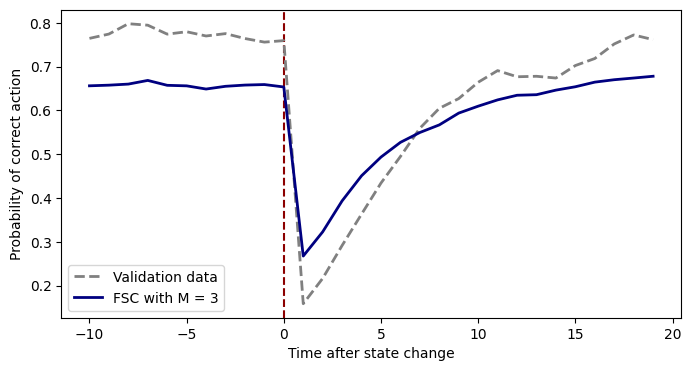

In [151]:
fig, ax = plt.subplots(figsize = (8, 4))
ax.plot(shifts_time, probs_correct_data_val.mean(axis = 0), c = "gray", lw = 2, ls = "--", label = "Validation data")
ax.plot(shifts_time, probs_correct_gen_M2, c = "navy", lw = 2, label = "FSC with M = 3")
ax.set_xlabel("Time after state change")
ax.set_ylabel("Probability of correct action")
ax.axvline(0, ls = "--", c = "darkred", zorder = -1)
plt.legend()
plt.show()

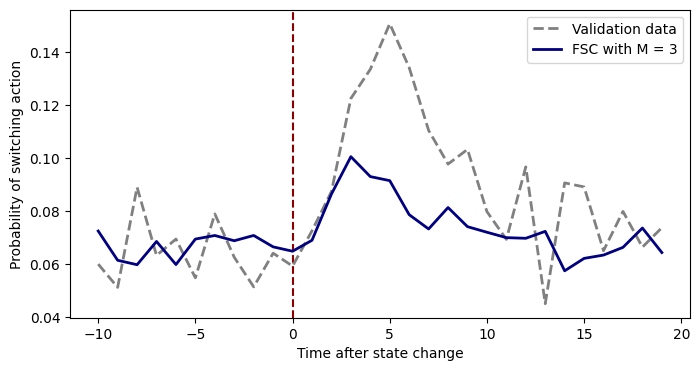

In [152]:
fig, ax = plt.subplots(figsize = (8, 4))
ax.plot(shifts_time, probs_switch_data_val.mean(axis = 0), c = "gray", lw = 2, ls = "--", label = "Validation data")
ax.plot(shifts_time, probs_switch_gen_M2, c = "navy", lw = 2, label = "FSC with M = 3")
ax.set_xlabel("Time after state change")
ax.set_ylabel("Probability of switching action")
ax.axvline(0, ls = "--", c = "darkred", zorder = -1)
plt.legend()
plt.show()

In [158]:
states_seq = np.concatenate((np.zeros(50), np.ones(50), np.zeros(50)))[..., None]
generated_trajectories_fixed_states_M2 = FSC_M2.generator.generate_trajectories_from_stateseq_obs_from_act(EModel = env,
                                                                  state_seq = states_seq,
                                                                  NTraj = 5000)

generated_memories_M2 = []

for idx_trj, gtrj in enumerate(generated_trajectories_fixed_states_M2):
    state_seq = []
    memory_seq = []

    for idx_t in range(len(states_seq) - 1):
        memory = gtrj["memories"][idx_t]
        memory_seq.append(np.where(np.array(MemSpace_M2) == memory)[0][0])

    generated_memories_M2.append(memory_seq)

generated_memories_M2 = np.array(generated_memories_M2).astype(int)

In [159]:
memory_occupation_M2 = np.zeros((generated_memories_M2.shape[1], len(MemSpace_M2)))
for idx_t in range(generated_memories_M2.shape[1]):
    currmem = generated_memories_M2[:, idx_t]
    bins = np.arange(len(MemSpace_M2) + 1) - 0.5
    memory_occupation_M2[idx_t] = np.histogram(currmem, bins=bins)[0]
    memory_occupation_M2[idx_t] /= np.sum(memory_occupation_M2[idx_t])

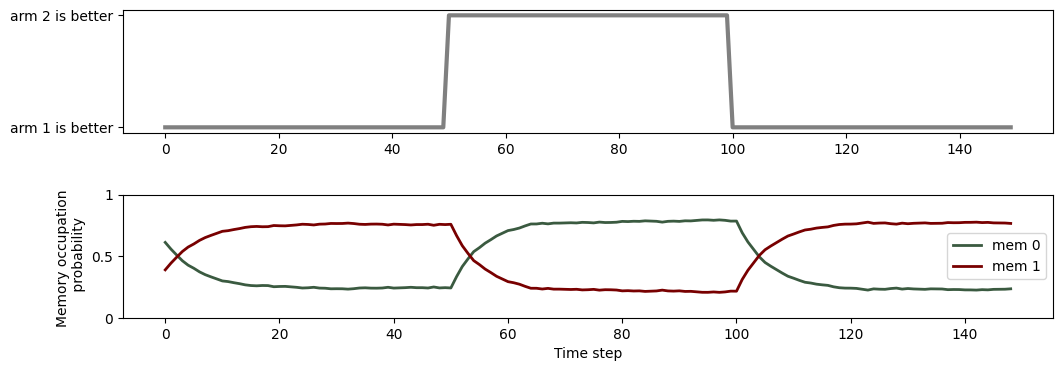

In [160]:
colors_memory = ["#3a5a40", "#780000"]

fig, axs = plt.subplots(2, 1, figsize = (12, 4))

axs[0].plot(states_seq, c = "gray", lw = 3)
axs[0].set_yticks([0,1])
axs[0].set_yticklabels(StatesSpace)

for i, idx_mem in enumerate(chain_ordering_M2):
    axs[1].plot(memory_occupation_M2[:, idx_mem], c = colors_memory[i], lw = 2, label = f"{MemSpace_M2[i]}")

axs[1].set_yticks([0, 0.5, 1])
axs[1].set_yticklabels([0, 0.5, 1])
axs[1].legend()
axs[1].set_ylabel("Memory occupation \n probability")
axs[1].set_xlabel("Time step")
plt.subplots_adjust(hspace=0.5)
plt.show()

# Analysis for M = 3

In [49]:
idx_M3 = 1
FSC_M3 = best_FSC_M_list[idx_M3]
MemSpace_M3 = MemSpaces_list[idx_M3]

print("Best loss for M =", FSC_M3.M, "is", FSC_M3.best_loss)

FSC_M3.set_mode("generation")
generated_trajectories = FSC_M3.generate_trajectories(environment_model = env,
                                                        NSteps = 200,
                                                        NTraj = len(initial_states_data_dict),
                                                        initial_states = initial_states_data_dict,
                                                        obs_from_act = True)

generated_rewards = 1 * (np.array([trj["observations"] for trj in generated_trajectories]) == "win")

Best loss for M = 3 is 142.20848093256637


/var/folders/tq/vdh27z_571gbg17w072s1p7h0000gn/T/ipykernel_58659/1707989453.py:30: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axs[1,0].legend()


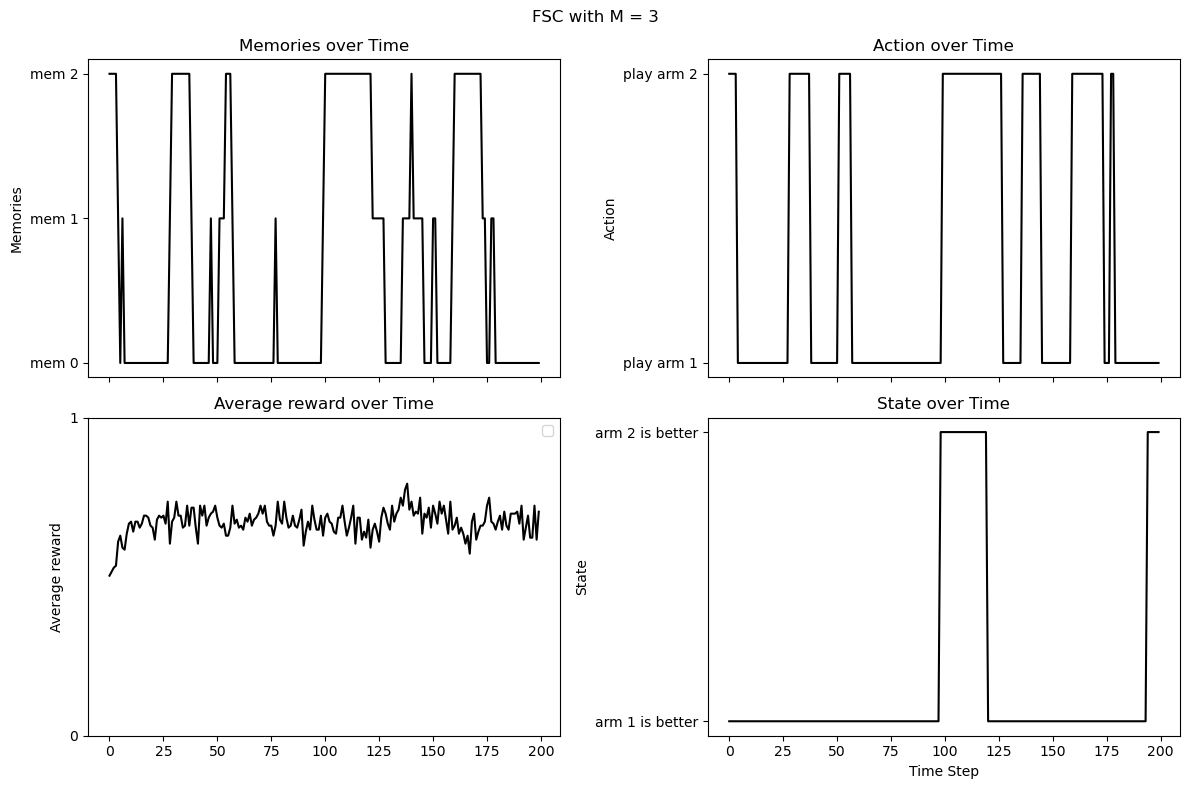

In [50]:
fig, axs = plt.subplots(2, 2, figsize=(12, 8), sharex=True)

fig.suptitle('FSC with M = ' + str(FSC_M3.M))

idx_traj = 0
trj = generated_trajectories[idx_traj]

act_numeric = [0 if act == "play arm 1" else 1 for act in trj["actions"]]
state_numeric = [state["better arm"] for state in trj["states"]]
# Map memory labels to indices according to MemSpaces
mem_label_to_idx = {mem: i for i, mem in enumerate(MemSpace_M3)}
mem_numeric = [mem_label_to_idx[m] for m in trj["memories"]]
axs[0, 0].plot(mem_numeric, alpha=1, color='k')
axs[0, 1].plot(act_numeric, alpha=1, color='k')

axs[1, 1].plot(state_numeric, alpha=1, color='k')

axs[0, 0].set_ylabel('Memories')
axs[0, 0].set_title('Memories over Time')
axs[0, 0].set_yticks(np.arange(len(MemSpace_M3)), MemSpace_M3)

axs[0, 1].set_ylabel('Action')
axs[0, 1].set_title('Action over Time')
axs[0, 1].set_yticks([0, 1], ActSpace)

axs[1, 0].plot(np.array(generated_rewards).mean(axis=0), alpha=1, color='k')
axs[1, 0].set_ylabel('Average reward')
axs[1, 0].set_title('Average reward over Time')
axs[1, 0].set_yticks([0, 1])
axs[1,0].legend()

axs[1, 1].set_ylabel('State')
axs[1, 1].set_title('State over Time')
axs[1, 1].set_xlabel('Time Step')
axs[1, 1].set_yticks([0, 1], StatesSpace)

plt.tight_layout()
plt.show()

In [51]:
idx_trj_st1 = 20
idx_trj_st2 = 0

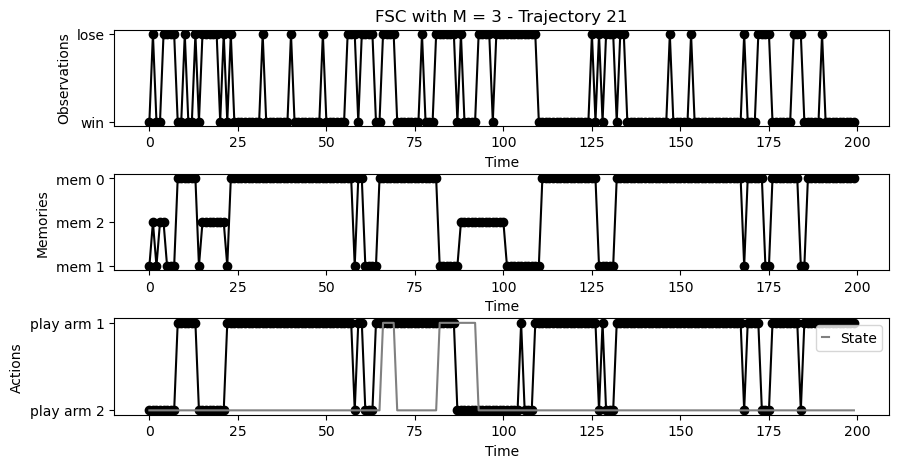

In [52]:
trj = generated_trajectories[idx_trj_st1]
fig, ax = FSC_M3.generator.plot_trajectory(trj)
ax[0].set_title('FSC with M = ' + str(FSC_M3.M) + ' - Trajectory ' + str(idx_trj_st1 + 1))
ax[2].plot([t["better arm"] for t in trj["states"]], c = "gray", label = "State", lw = 1.5)

ax[2].legend(handlelength = 0.5)
plt.show()

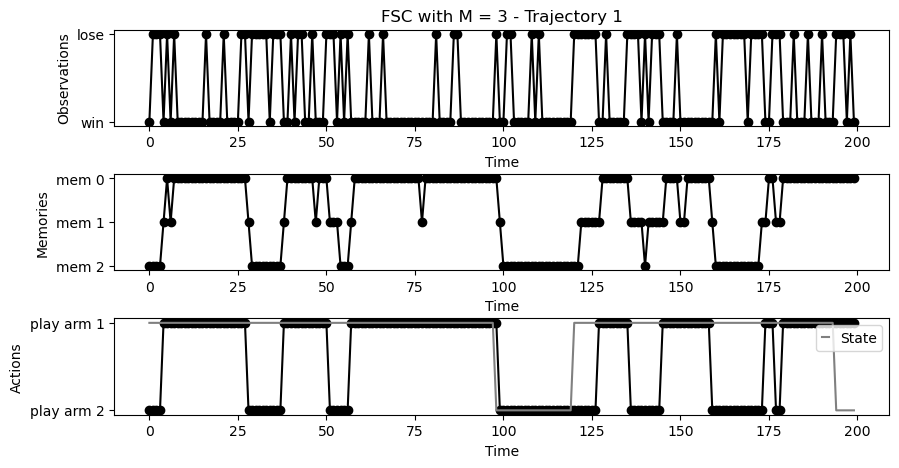

In [53]:
trj = generated_trajectories[idx_trj_st2]
fig, ax = FSC_M3.generator.plot_trajectory(trj)
ax[0].set_title('FSC with M = ' + str(FSC_M3.M) + ' - Trajectory ' + str(idx_trj_st2 + 1))
ax[2].plot([1 - t["better arm"] for t in trj["states"]], c = "gray", label = "State", lw = 1.5)

ax[2].legend(handlelength = 0.5)
plt.show()

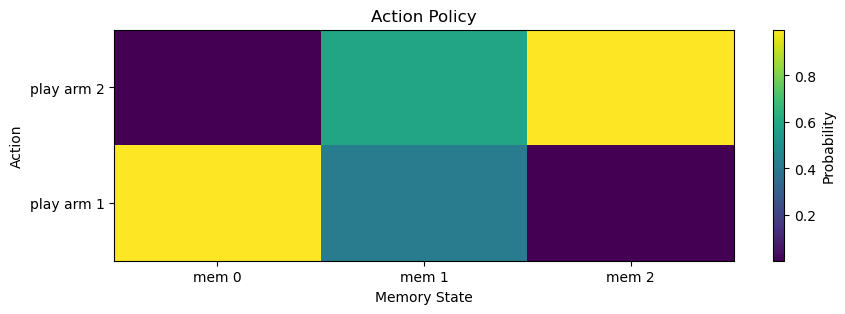

In [54]:
fig, ax = plt.subplots(figsize=(10, 3))
c = ax.pcolormesh(MemSpace_M3, ActSpace, FSC_M3.get_action_policy().T)
ax.set_xlabel('Memory State')
ax.set_ylabel('Action')
ax.set_title('Action Policy')
fig.colorbar(c, ax=ax, label='Probability', orientation='vertical')
plt.show()

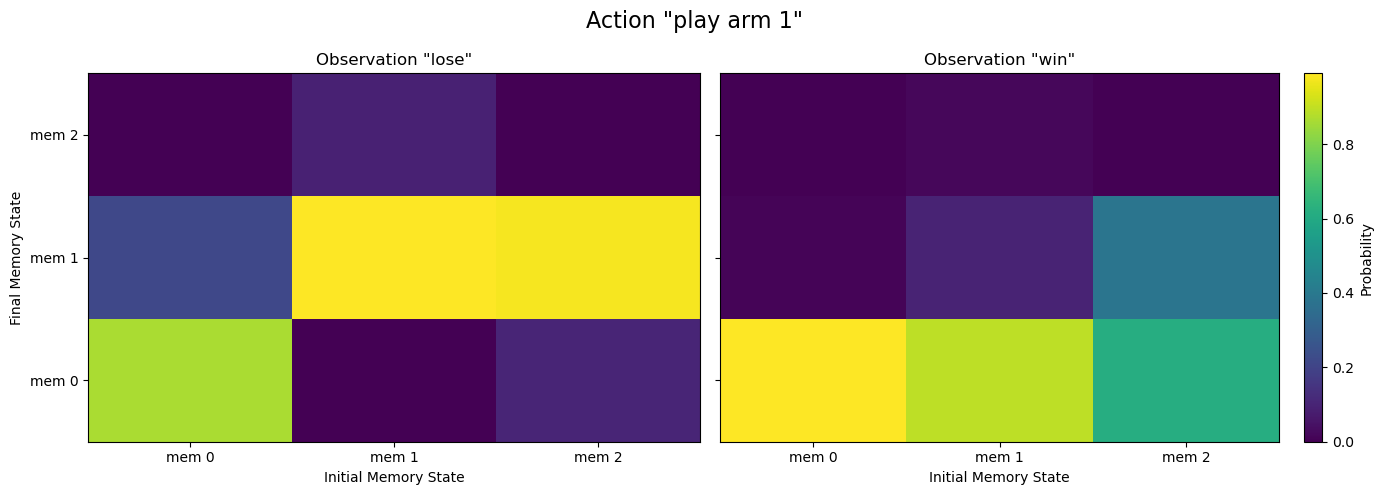

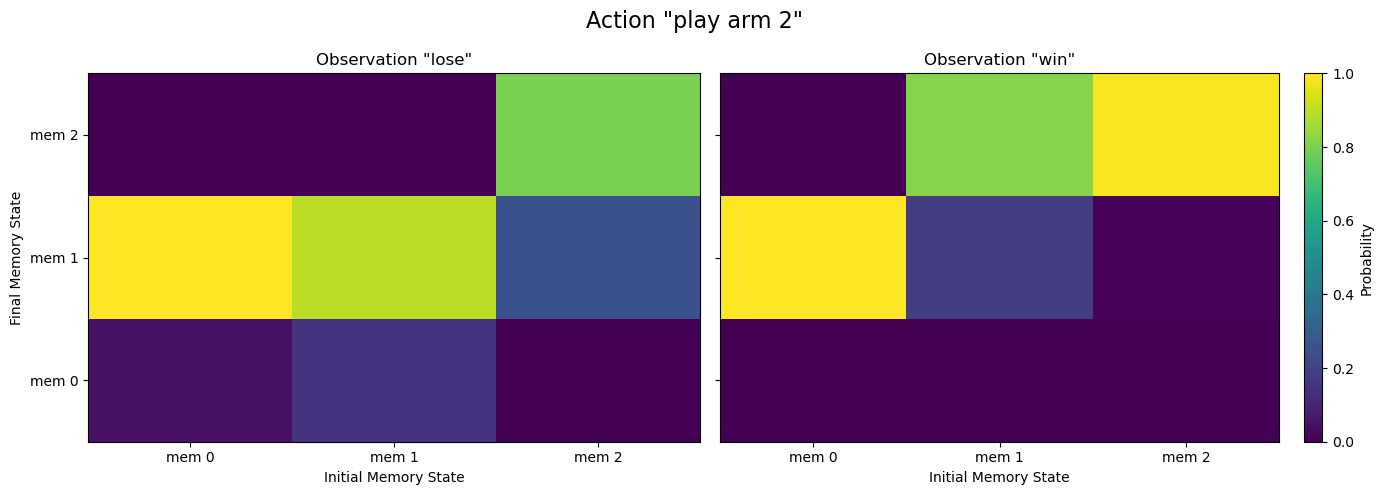

In [55]:
for idx_act in range(len(ActSpace)):
    fig, axs = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
    for idx_obs in range(len(ObsSpace)):
        c = axs[idx_obs].pcolormesh(
            MemSpace_M3,
            MemSpace_M3,
            FSC_M3.get_memory_transitions()[idx_obs][idx_act].T
        )
        axs[idx_obs].set_xlabel('Initial Memory State')
        axs[idx_obs].set_title(f'Observation "{ObsSpace[idx_obs]}"')
        fig.suptitle(f'Action "{ActSpace[idx_act]}"', fontsize=16)
        if idx_obs == 0:
            axs[idx_obs].set_ylabel('Final Memory State')
        if idx_obs == 1:
            fig.colorbar(c, ax=axs[idx_obs], label='Probability', orientation='vertical', fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.show()

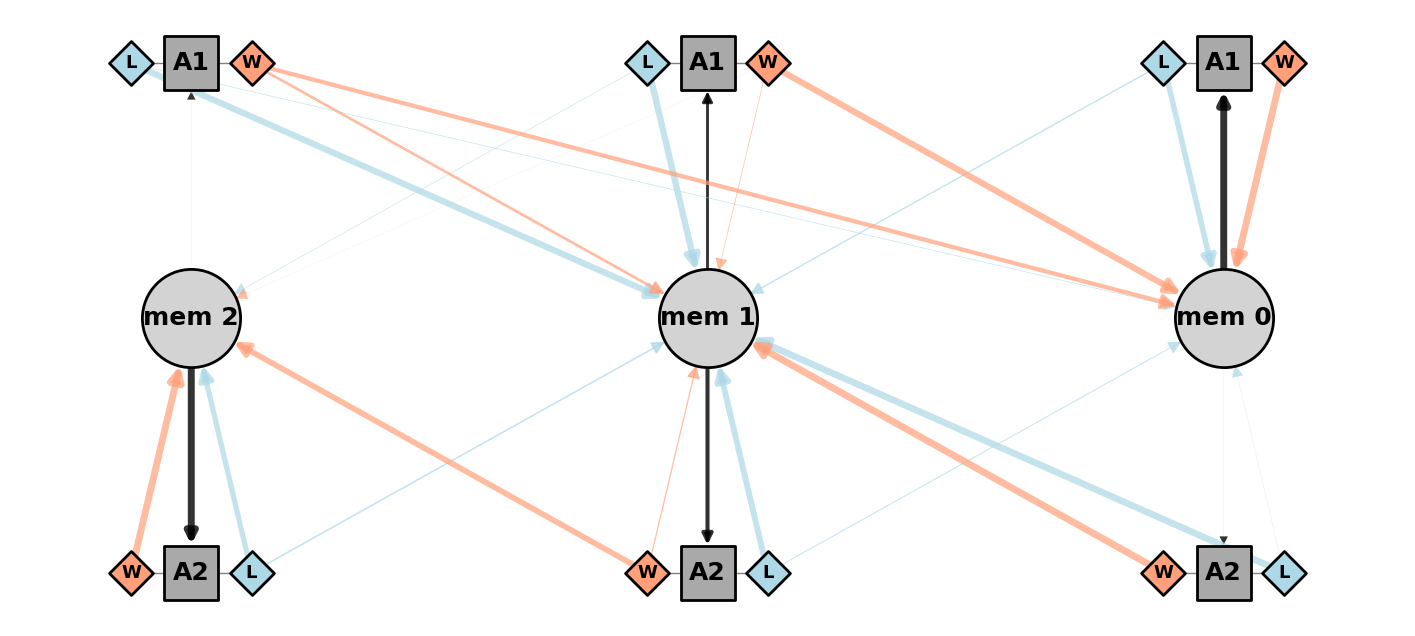

In [56]:
chain_ordering_M3 = utils.get_optimized_memory_order(
    FSC_M3.get_action_policy(),
    FSC_M3.get_memory_transitions(),
    action_threshold=0.6,
    fade_no_incoming=True,
    min_weight_threshold=0.01,
    reverse_left_part = True,
    reverse_right_part = True
)

ax = FSC_M3.plot_FSC(observation_node_colors=['lightblue', 'lightsalmon'], memory_ordering = chain_ordering_M3,
                     action_names=['A1', 'A2'], observation_names=['L', 'W'],
                     th_action_probs=1e-3, th_mem_transitions=1e-3)
plt.show()

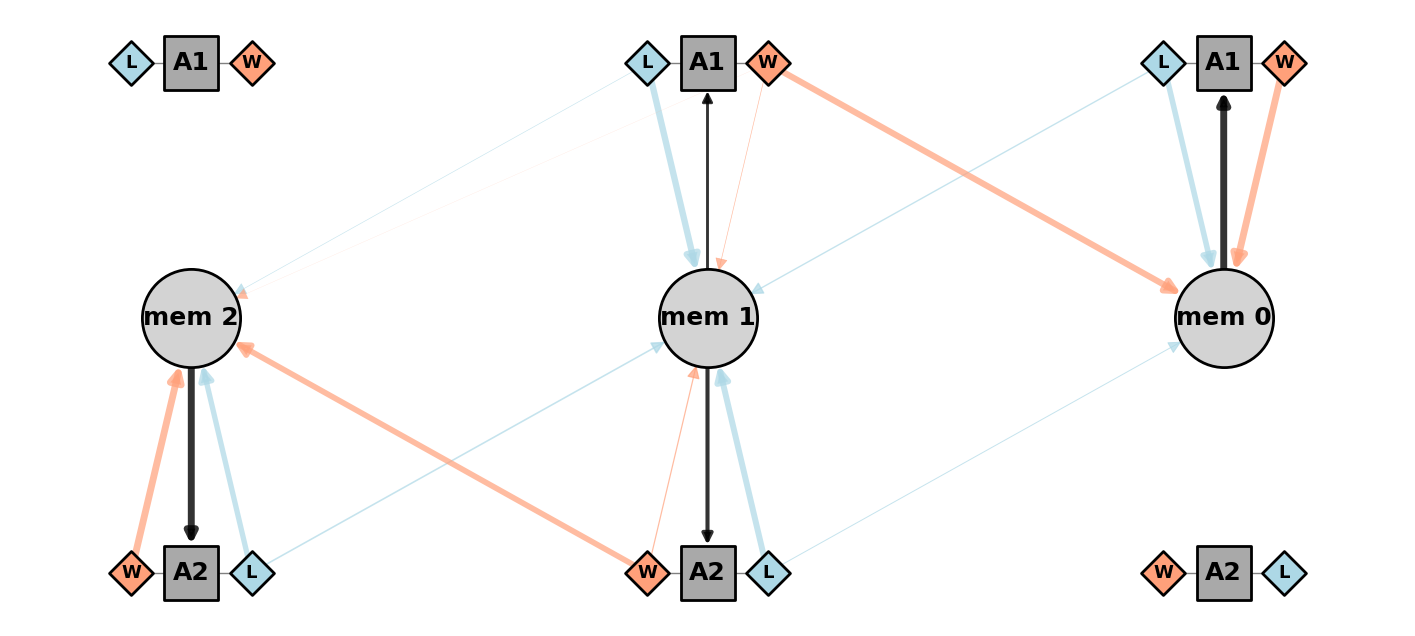

Loss of the cut FSC: 143.5859418055083
Loss of the original FSC: 142.20849204773353


In [57]:
FSC_M3_cut = controller.FSC(M = FSC_M3.M, A = FSC_M3.A, Y = FSC_M3.Y,
                            mode = "generation",
                            policy_model = "softmax",
                            policy_params = {"theta": FSC_M3.policy_params["theta"].copy(), "zeta": FSC_M3.policy_params["zeta"].copy()},
                            psi = FSC_M3.psi.copy(),
                            ActSpace = FSC_M3.ActSpace, MemSpace = FSC_M3.MemSpace,
                            ObsSpace = FSC_M3.ObsSpace)

FSC_M3_cut.GPModel.zeta[np.where(FSC_M3.get_action_policy().T < 1e-1)] = -np.inf

ax = FSC_M3.plot_FSC(observation_node_colors=['lightblue', 'lightsalmon'], memory_ordering = chain_ordering_M3,
                     action_names=['A1', 'A2'], observation_names=['L', 'W'],
                     th_action_probs=1e-1, th_mem_transitions=1e-3)
plt.show()

print("Loss of the cut FSC:", FSC_M3_cut.compute_loss(trajectories_data_val))
print("Loss of the original FSC:", FSC_M3.compute_loss(trajectories_data_val))

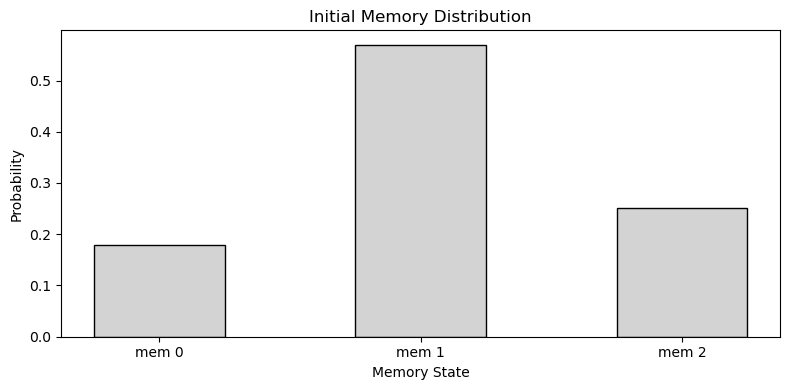

In [72]:
rho = FSC_M3.rho

# rho is the initial distribution of memory states, make an histogram of it
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(np.arange(len(rho)), rho, color='lightgray', edgecolor='k', width=0.5)
ax.set_xlabel('Memory State')
ax.set_ylabel('Probability')
ax.set_title('Initial Memory Distribution')
ax.set_xticks(np.arange(len(MemSpace_M3)), MemSpace_M3)
plt.tight_layout()
plt.show()

In [285]:
generated_trajectories_M3 = FSC_M3.generate_trajectories(environment_model = env,
                                                        NSteps = np.max(np.concatenate(durations_train + durations_val)),
                                                        NTraj = len(initial_states_data_dict),
                                                        initial_states = initial_states_data_dict,
                                                        obs_from_act = True)

generated_rewards_M3 = 1 * (np.array([trj["observations"] for trj in generated_trajectories_M3]) == "win")

In [286]:
for idx_trj, dur in enumerate(np.concatenate(durations_train + durations_val)):
    for key in generated_trajectories_M3[idx_trj].keys():
        generated_trajectories_M3[idx_trj][key] = generated_trajectories_M3[idx_trj][key][:dur]

In [287]:
idx_start = -10
idx_end = 20
shifts_time = np.arange(idx_start, idx_end)

probs_correct_gen_M3, probs_switch_gen_M3 = compute_shift_observables_from_trjs(generated_trajectories_M3,
                                                                                idx_start=idx_start,
                                                                                idx_end=idx_end)

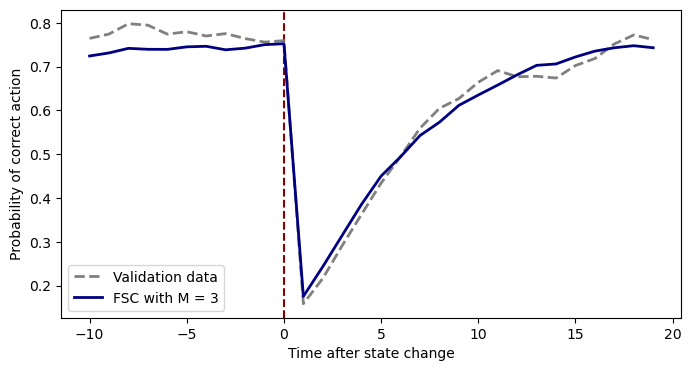

In [288]:
fig, ax = plt.subplots(figsize = (8, 4))
ax.plot(shifts_time, probs_correct_data_val.mean(axis = 0), c = "gray", lw = 2, ls = "--", label = "Validation data")
ax.plot(shifts_time, probs_correct_gen_M3, c = "navy", lw = 2, label = "FSC with M = 3")
ax.set_xlabel("Time after state change")
ax.set_ylabel("Probability of correct action")
ax.axvline(0, ls = "--", c = "darkred", zorder = -1)
plt.legend()
plt.show()

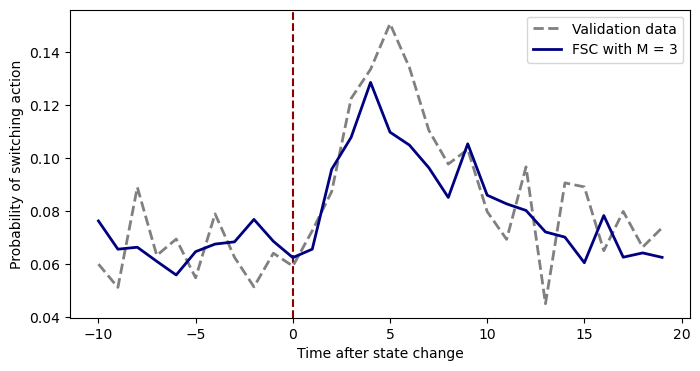

In [289]:
fig, ax = plt.subplots(figsize = (8, 4))
ax.plot(shifts_time, probs_switch_data_val.mean(axis = 0), c = "gray", lw = 2, ls = "--", label = "Validation data")
ax.plot(shifts_time, probs_switch_gen_M3, c = "navy", lw = 2, label = "FSC with M = 3")
ax.set_xlabel("Time after state change")
ax.set_ylabel("Probability of switching action")
ax.axvline(0, ls = "--", c = "darkred", zorder = -1)
plt.legend()
plt.show()

In [ ]:
states_seq = np.concatenate((np.zeros(50), np.ones(50), np.zeros(50)))[..., None]
generated_trajectories_fixed_states_M3 = FSC_M3.generator.generate_trajectories_from_stateseq_obs_from_act(EModel = env,
                                                                  state_seq = states_seq,
                                                                  NTraj = 5000)

generated_memories_M3 = []

for idx_trj, gtrj in enumerate(generated_trajectories_fixed_states_M3):
    memory_seq = []
    obs_seq = []

    for idx_t in range(len(states_seq) - 1):
        memory = gtrj["memories"][idx_t]
        memory_seq.append(np.where(np.array(MemSpace_M3) == memory)[0][0])

        obs = gtrj["observations"][idx_t]
        obs_num = np.zeros_like(obs)
        obs_num[obs == "win"] = 1
        obs_num[obs == "lose"] = 0
        obs_seq.append(np.array(obs_num).astype(int))

    generated_memories_M3.append(memory_seq)

generated_memories_M3 = np.array(generated_memories_M3).astype(int)

In [298]:
memory_occupation_M3 = np.zeros((generated_memories_M3.shape[1], len(MemSpace_M3)))
for idx_t in range(generated_memories_M3.shape[1]):
    currmem = generated_memories_M3[:, idx_t]
    bins = np.arange(len(MemSpace_M3) + 1) - 0.5
    memory_occupation_M3[idx_t] = np.histogram(currmem, bins=bins)[0]
    memory_occupation_M3[idx_t] /= np.sum(memory_occupation_M3[idx_t])

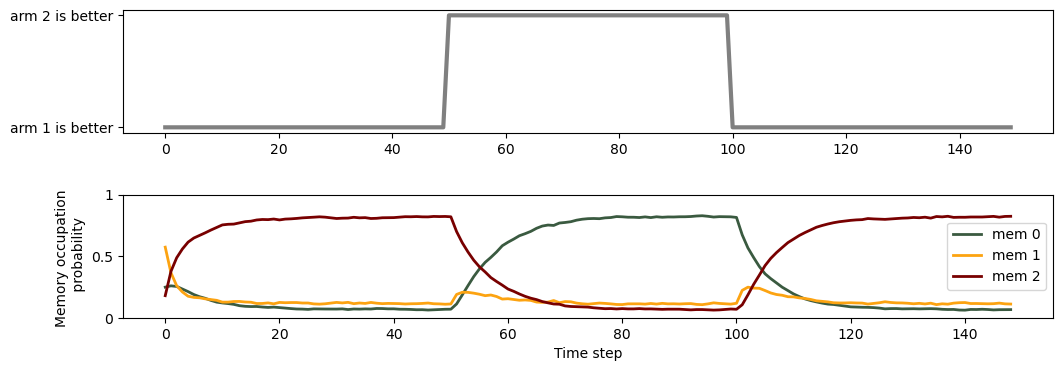

In [301]:
colors_memory = ["#3a5a40", "#fca311", "#780000"]

fig, axs = plt.subplots(2, 1, figsize = (12, 4))

axs[0].plot(states_seq, c = "gray", lw = 3)
axs[0].set_yticks([0,1])
axs[0].set_yticklabels(StatesSpace)

for i, idx_mem in enumerate(chain_ordering_M3):
    axs[1].plot(memory_occupation_M3[:, idx_mem], c = colors_memory[i], lw = 2, label = f"{MemSpace_M3[i]}")

axs[1].set_yticks([0, 0.5, 1])
axs[1].set_yticklabels([0, 0.5, 1])
axs[1].legend()
axs[1].set_ylabel("Memory occupation \n probability")
axs[1].set_xlabel("Time step")
plt.subplots_adjust(hspace=0.5)
plt.show()

# Analysis for M = 4

In [341]:
idx_M4 = 2
FSC_M4 = best_FSC_M_list[idx_M4]
MemSpace_M4 = MemSpaces_list[idx_M4]

print("Best loss for M =", FSC_M4.M, "is", FSC_M4.best_loss)

FSC_M4.set_mode("generation")
generated_trajectories = FSC_M4.generate_trajectories(environment_model = env,
                                                        NSteps = 200,
                                                        NTraj = len(initial_states_data_dict),
                                                        initial_states = initial_states_data_dict,
                                                        obs_from_act = True)

generated_rewards = 1 * (np.array([trj["observations"] for trj in generated_trajectories]) == "win")

Best loss for M = 4 is 137.57311631726327


/var/folders/tq/vdh27z_571gbg17w072s1p7h0000gn/T/ipykernel_58659/1954308540.py:30: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axs[1,0].legend()


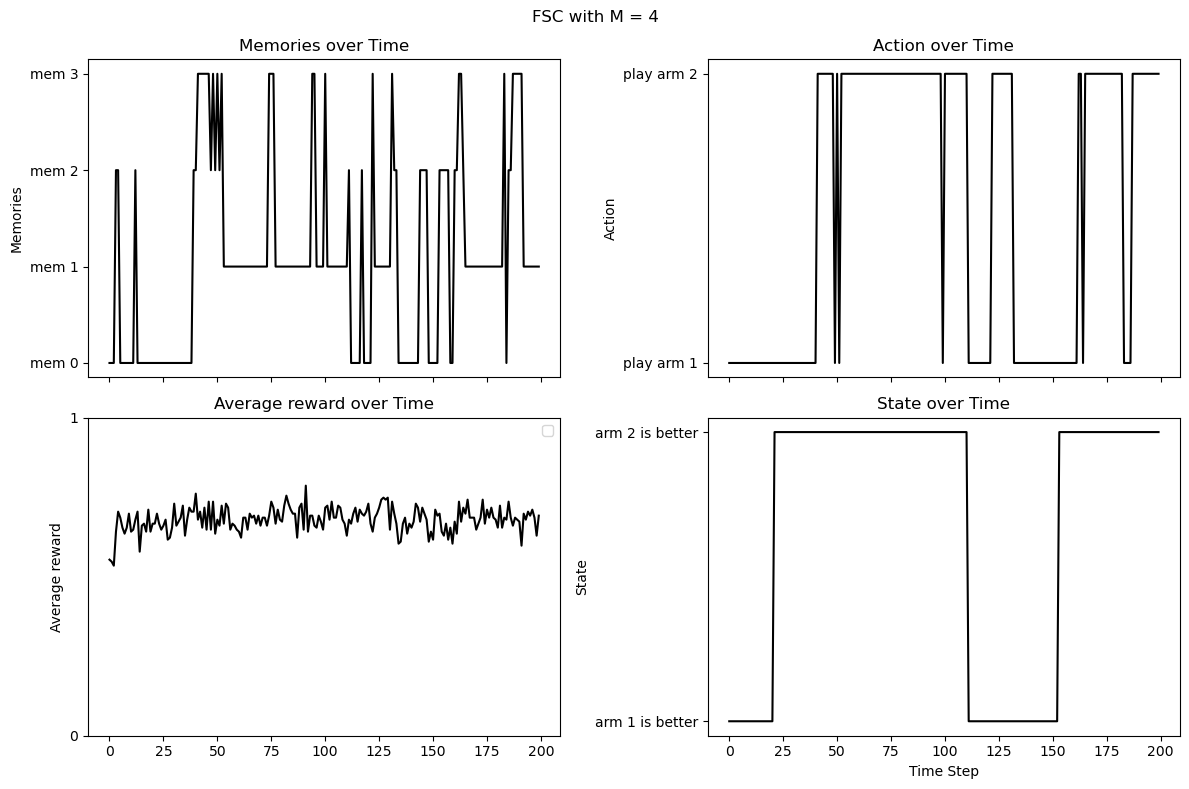

In [342]:
fig, axs = plt.subplots(2, 2, figsize=(12, 8), sharex=True)

fig.suptitle('FSC with M = ' + str(FSC_M4.M))

idx_traj = 0
trj = generated_trajectories[idx_traj]

act_numeric = [0 if act == "play arm 1" else 1 for act in trj["actions"]]
state_numeric = [state["better arm"] for state in trj["states"]]
# Map memory labels to indices according to MemSpaces
mem_label_to_idx = {mem: i for i, mem in enumerate(MemSpace_M4)}
mem_numeric = [mem_label_to_idx[m] for m in trj["memories"]]
axs[0, 0].plot(mem_numeric, alpha=1, color='k')
axs[0, 1].plot(act_numeric, alpha=1, color='k')

axs[1, 1].plot(state_numeric, alpha=1, color='k')

axs[0, 0].set_ylabel('Memories')
axs[0, 0].set_title('Memories over Time')
axs[0, 0].set_yticks(np.arange(len(MemSpace_M4)), MemSpace_M4)

axs[0, 1].set_ylabel('Action')
axs[0, 1].set_title('Action over Time')
axs[0, 1].set_yticks([0, 1], ActSpace)

axs[1, 0].plot(np.array(generated_rewards).mean(axis=0), alpha=1, color='k')
axs[1, 0].set_ylabel('Average reward')
axs[1, 0].set_title('Average reward over Time')
axs[1, 0].set_yticks([0, 1])
axs[1,0].legend()

axs[1, 1].set_ylabel('State')
axs[1, 1].set_title('State over Time')
axs[1, 1].set_xlabel('Time Step')
axs[1, 1].set_yticks([0, 1], StatesSpace)

plt.tight_layout()
plt.show()

In [343]:
idx_trj_st1 = 20
idx_trj_st2 = 0

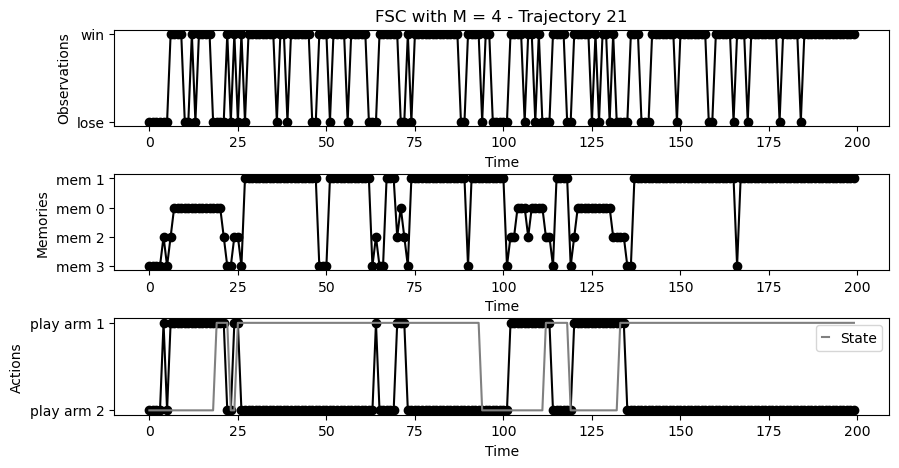

In [344]:
trj = generated_trajectories[idx_trj_st1]
fig, ax = FSC_M4.generator.plot_trajectory(trj)
ax[0].set_title('FSC with M = ' + str(FSC_M4.M) + ' - Trajectory ' + str(idx_trj_st1 + 1))
ax[2].plot([t["better arm"] for t in trj["states"]], c = "gray", label = "State", lw = 1.5)

ax[2].legend(handlelength = 0.5)
plt.show()

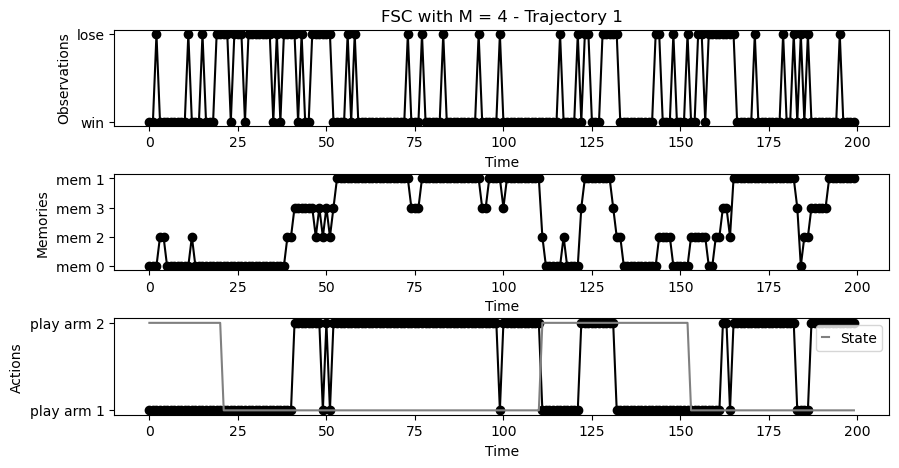

In [345]:
trj = generated_trajectories[idx_trj_st2]
fig, ax = FSC_M4.generator.plot_trajectory(trj)
ax[0].set_title('FSC with M = ' + str(FSC_M4.M) + ' - Trajectory ' + str(idx_trj_st2 + 1))
ax[2].plot([1 - t["better arm"] for t in trj["states"]], c = "gray", label = "State", lw = 1.5)

ax[2].legend(handlelength = 0.5)
plt.show()

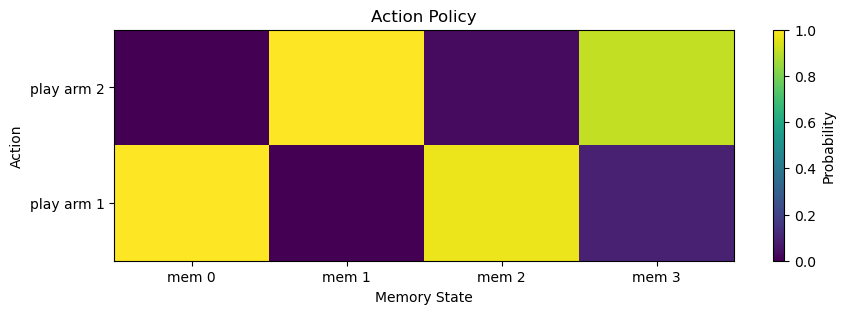

In [346]:
fig, ax = plt.subplots(figsize=(10, 3))
c = ax.pcolormesh(MemSpace_M4, ActSpace, FSC_M4.get_action_policy().T)
ax.set_xlabel('Memory State')
ax.set_ylabel('Action')
ax.set_title('Action Policy')
fig.colorbar(c, ax=ax, label='Probability', orientation='vertical')
plt.show()

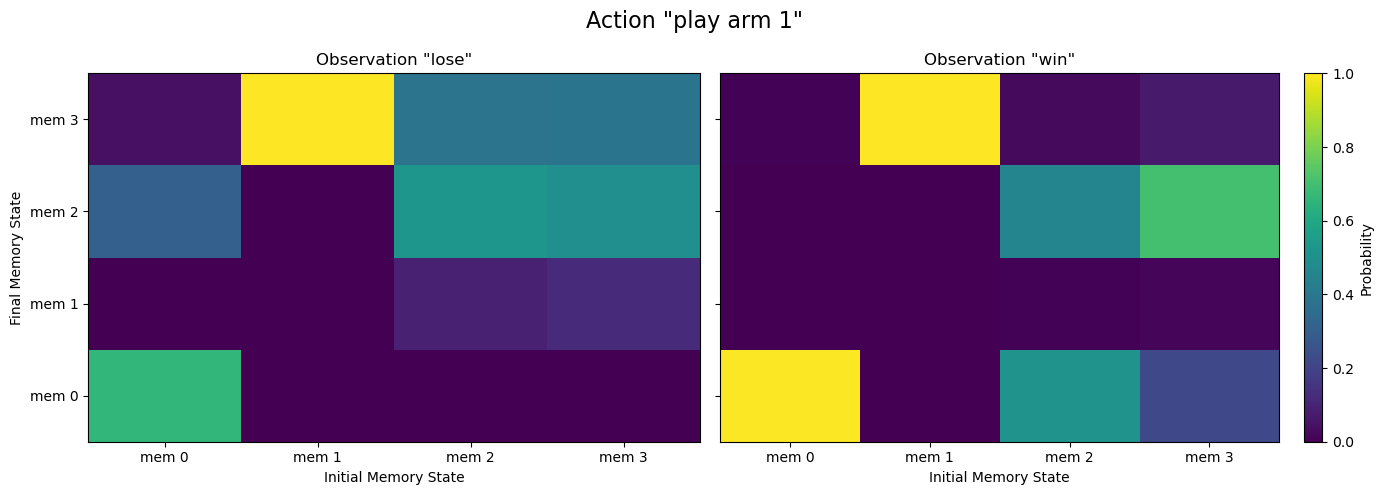

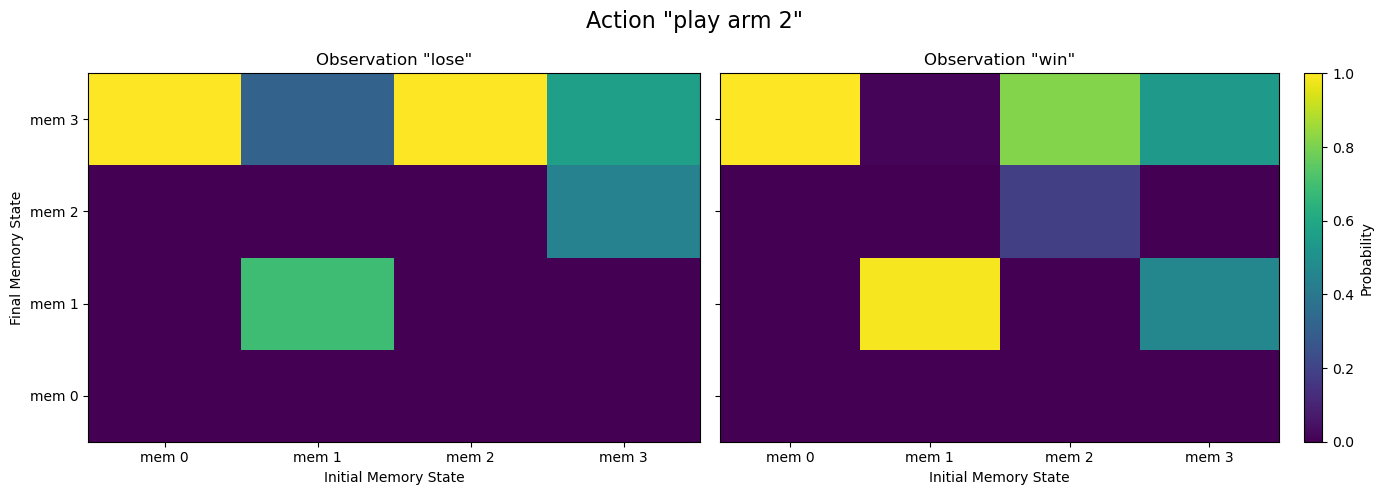

In [347]:
for idx_act in range(len(ActSpace)):
    fig, axs = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
    for idx_obs in range(len(ObsSpace)):
        c = axs[idx_obs].pcolormesh(
            MemSpace_M4,
            MemSpace_M4,
            FSC_M4.get_memory_transitions()[idx_obs][idx_act].T
        )
        axs[idx_obs].set_xlabel('Initial Memory State')
        axs[idx_obs].set_title(f'Observation "{ObsSpace[idx_obs]}"')
        fig.suptitle(f'Action "{ActSpace[idx_act]}"', fontsize=16)
        if idx_obs == 0:
            axs[idx_obs].set_ylabel('Final Memory State')
        if idx_obs == 1:
            fig.colorbar(c, ax=axs[idx_obs], label='Probability', orientation='vertical', fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.show()

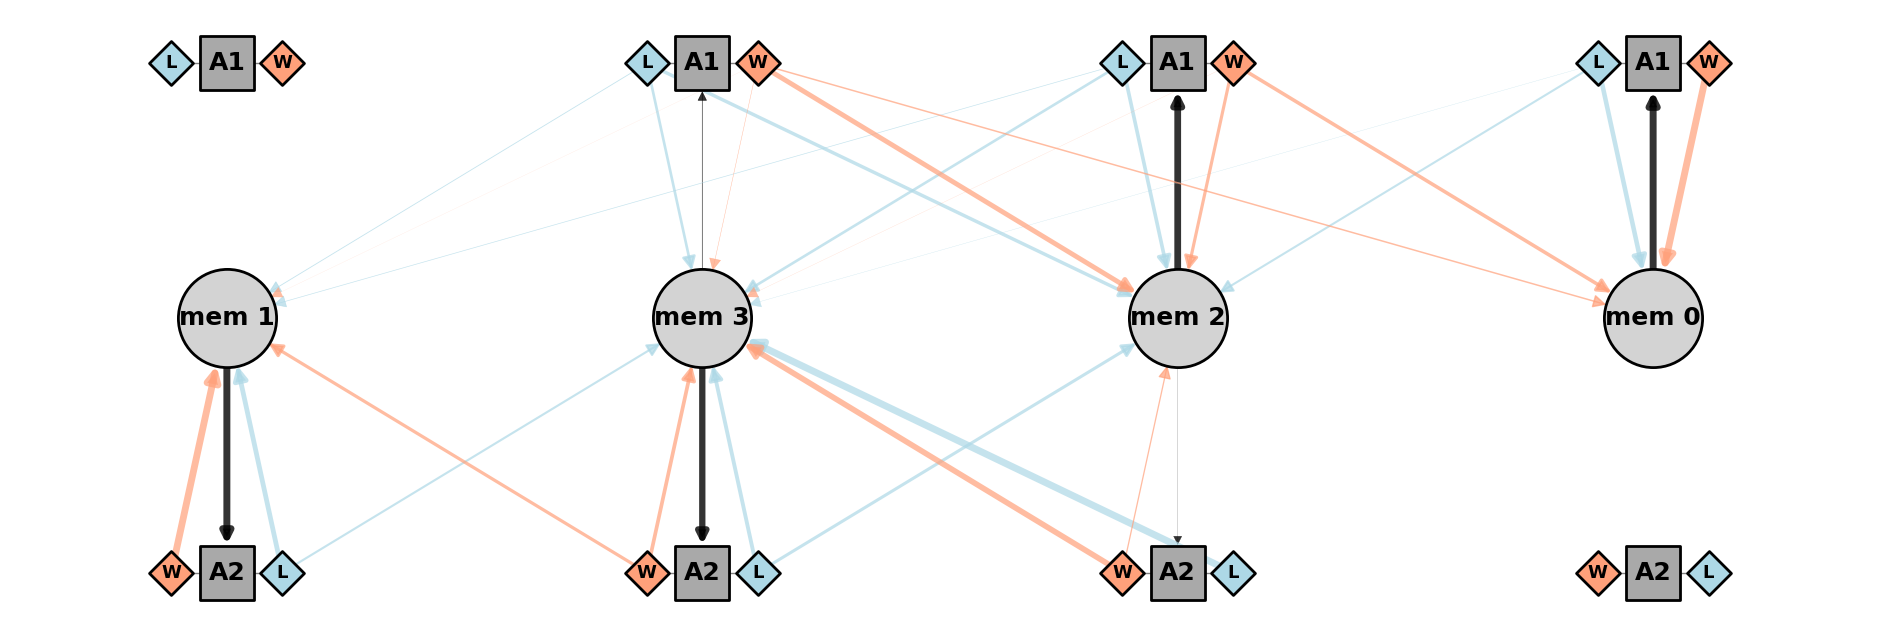

In [348]:
chain_ordering_M4 = utils.get_optimized_memory_order(
    FSC_M4.get_action_policy(),
    FSC_M4.get_memory_transitions(),
    action_threshold=0.6,
    fade_no_incoming=True,
    min_weight_threshold=0.01,
    reverse_left_part = False,
    reverse_right_part = True
)

ax = FSC_M4.plot_FSC(observation_node_colors=['lightblue', 'lightsalmon'], memory_ordering = chain_ordering_M4,
                     action_names=['A1', 'A2'], observation_names=['L', 'W'],
                     th_action_probs=1e-3, th_mem_transitions=1e-3)
plt.show()

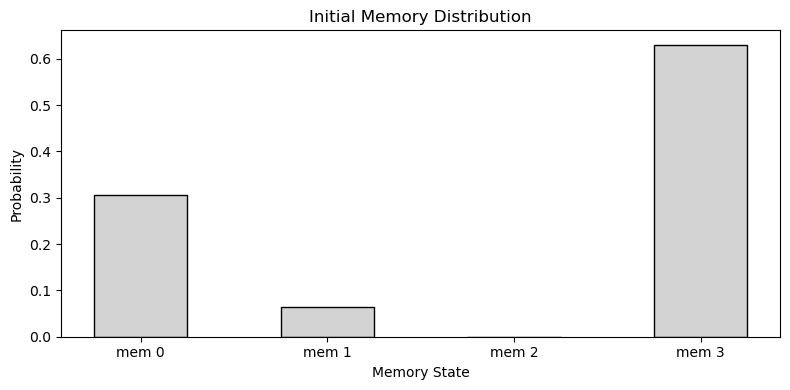

In [358]:
rho = FSC_M4.rho

# rho is the initial distribution of memory states, make an histogram of it
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(np.arange(len(rho)), rho, color='lightgray', edgecolor='k', width=0.5)
ax.set_xlabel('Memory State')
ax.set_ylabel('Probability')
ax.set_title('Initial Memory Distribution')
ax.set_xticks(np.arange(len(MemSpace_M4)), MemSpace_M4)
plt.tight_layout()
plt.show()

In [372]:
generated_trajectories_M4 = FSC_M4.generate_trajectories(environment_model = env,
                                                        NSteps = np.max(np.concatenate(durations_train + durations_val)),
                                                        NTraj = len(initial_states_data_dict),
                                                        initial_states = initial_states_data_dict,
                                                        obs_from_act = True)

generated_rewards_M4 = 1 * (np.array([trj["observations"] for trj in generated_trajectories_M4]) == "win")

In [373]:
for idx_trj, dur in enumerate(np.concatenate(durations_train + durations_val)):
    for key in generated_trajectories_M4[idx_trj].keys():
        generated_trajectories_M4[idx_trj][key] = generated_trajectories_M4[idx_trj][key][:dur]

In [374]:
idx_start = -10
idx_end = 20
shifts_time = np.arange(idx_start, idx_end)

probs_correct_gen_M4, probs_switch_gen_M4 = compute_shift_observables_from_trjs(generated_trajectories_M4,
                                                                                idx_start=idx_start,
                                                                                idx_end=idx_end)

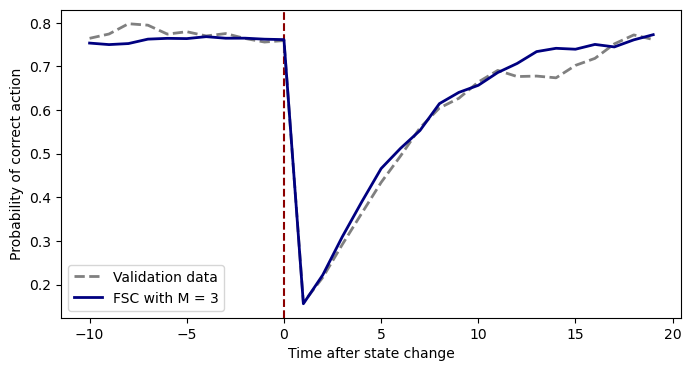

In [375]:
fig, ax = plt.subplots(figsize = (8, 4))
ax.plot(shifts_time, probs_correct_data_val.mean(axis = 0), c = "gray", lw = 2, ls = "--", label = "Validation data")
ax.plot(shifts_time, probs_correct_gen_M4, c = "navy", lw = 2, label = "FSC with M = 3")
ax.set_xlabel("Time after state change")
ax.set_ylabel("Probability of correct action")
ax.axvline(0, ls = "--", c = "darkred", zorder = -1)
plt.legend()
plt.show()

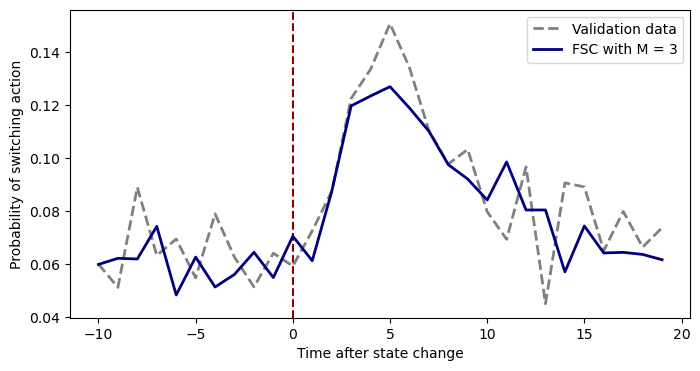

In [376]:
fig, ax = plt.subplots(figsize = (8, 4))
ax.plot(shifts_time, probs_switch_data_val.mean(axis = 0), c = "gray", lw = 2, ls = "--", label = "Validation data")
ax.plot(shifts_time, probs_switch_gen_M4, c = "navy", lw = 2, label = "FSC with M = 3")
ax.set_xlabel("Time after state change")
ax.set_ylabel("Probability of switching action")
ax.axvline(0, ls = "--", c = "darkred", zorder = -1)
plt.legend()
plt.show()

In [377]:
states_seq = np.concatenate((np.zeros(50), np.ones(50), np.zeros(50)))[..., None]
generated_trajectories_fixed_states_M4 = FSC_M4.generator.generate_trajectories_from_stateseq_obs_from_act(EModel = env,
                                                                  state_seq = states_seq,
                                                                  NTraj = 5000)

generated_memories_M4 = []

for idx_trj, gtrj in enumerate(generated_trajectories_fixed_states_M4):
    state_seq = []
    memory_seq = []

    for idx_t in range(len(states_seq) - 1):
        memory = gtrj["memories"][idx_t]
        memory_seq.append(np.where(np.array(MemSpace_M4) == memory)[0][0])

    generated_memories_M4.append(memory_seq)

generated_memories_M4 = np.array(generated_memories_M4).astype(int)

In [378]:
memory_occupation_M4 = np.zeros((generated_memories_M4.shape[1], len(MemSpace_M4)))
for idx_t in range(generated_memories_M4.shape[1]):
    currmem = generated_memories_M4[:, idx_t]
    bins = np.arange(len(MemSpace_M4) + 1) - 0.5
    memory_occupation_M4[idx_t] = np.histogram(currmem, bins=bins)[0]
    memory_occupation_M4[idx_t] /= np.sum(memory_occupation_M4[idx_t])

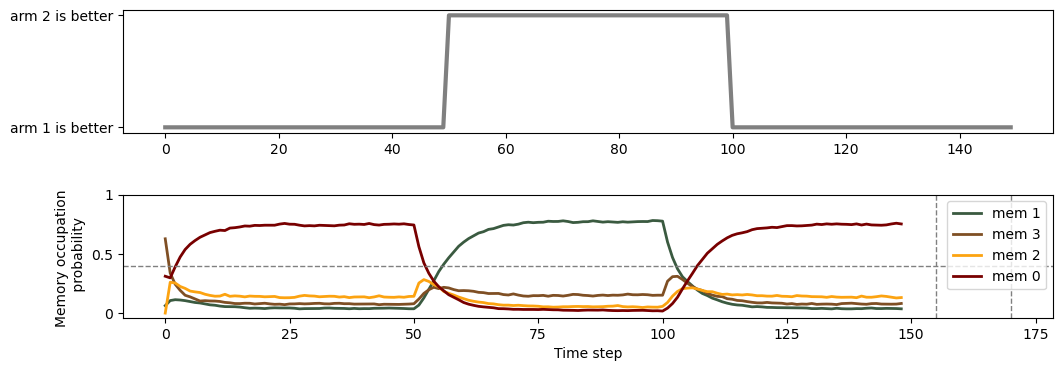

In [448]:
colors_memory = ["#3a5a40", "#7f4f24", "#fca311", "#780000"]

fig, axs = plt.subplots(2, 1, figsize = (12, 4))

axs[0].plot(states_seq, c = "gray", lw = 3)
axs[0].set_yticks([0,1])
axs[0].set_yticklabels(StatesSpace)

for i, idx_mem in enumerate(chain_ordering_M4):
    axs[1].plot(memory_occupation_M4[:, idx_mem], c = colors_memory[i], lw = 2, label = f"{MemSpace_M4[idx_mem]}")

axs[1].set_yticks([0, 0.5, 1])
axs[1].set_yticklabels([0, 0.5, 1])
axs[1].legend()
axs[1].set_ylabel("Memory occupation \n probability")
axs[1].set_xlabel("Time step")
axs[1].axvline(155, color='gray', linestyle='--', linewidth=1)
axs[1].axvline(170, color='gray', linestyle='--', linewidth=1)
axs[1].axhline(0.4, color='gray', linestyle='--', linewidth=1)
plt.subplots_adjust(hspace=0.5)
plt.show()

# Generation of data from other Ms

Best loss for M = 5 is 137.04984817253217


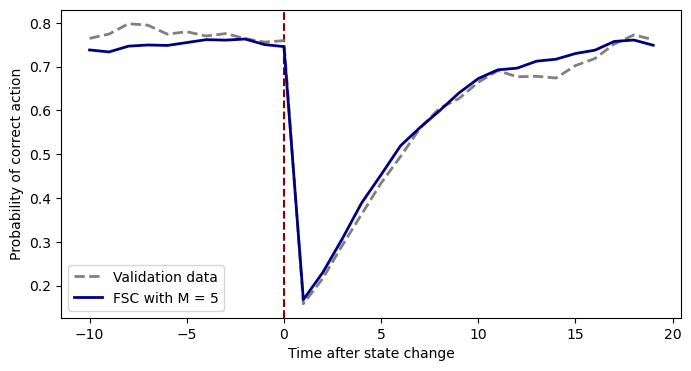

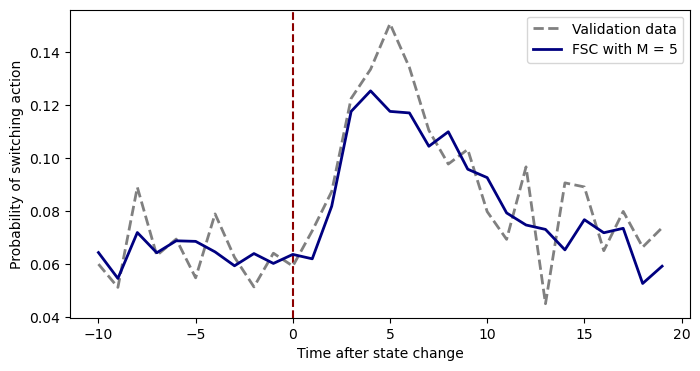

Best loss for M = 6 is 136.6628336305462


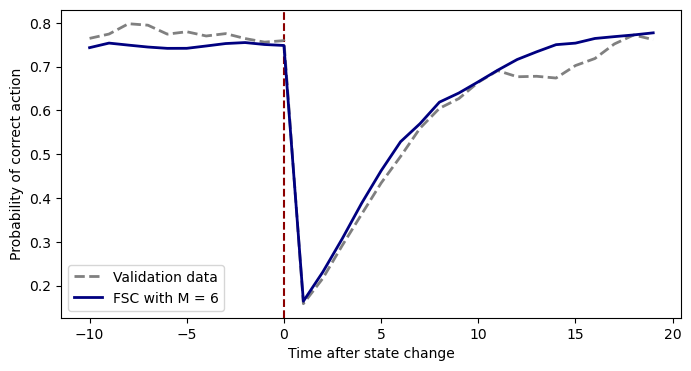

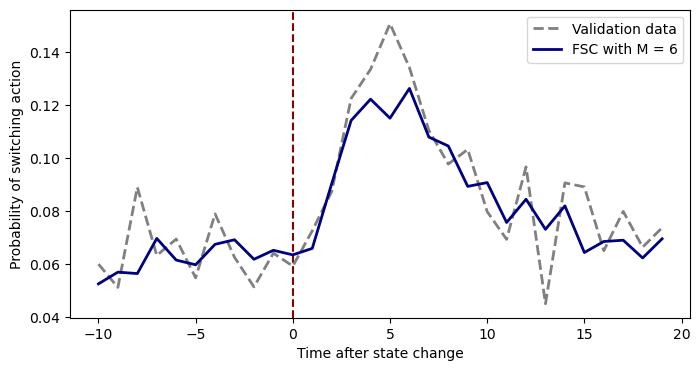

Best loss for M = 7 is 136.69659008004942


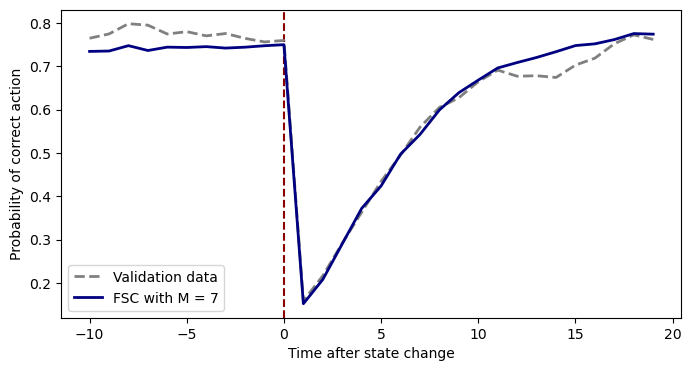

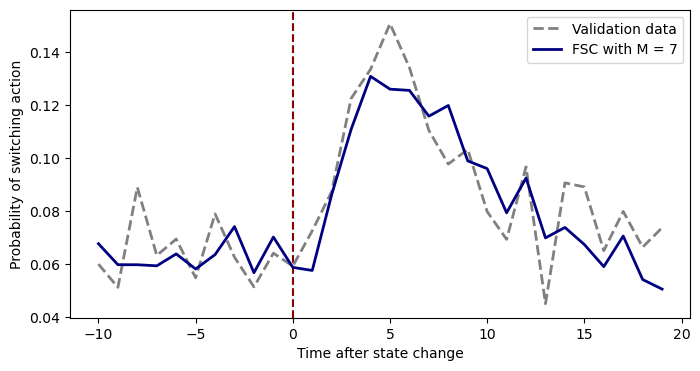

Best loss for M = 8 is 136.7151229395883


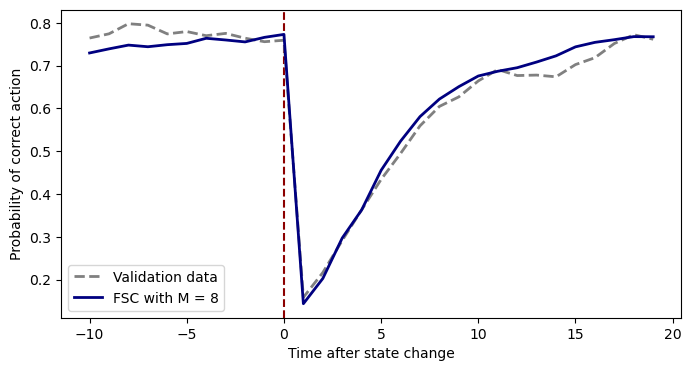

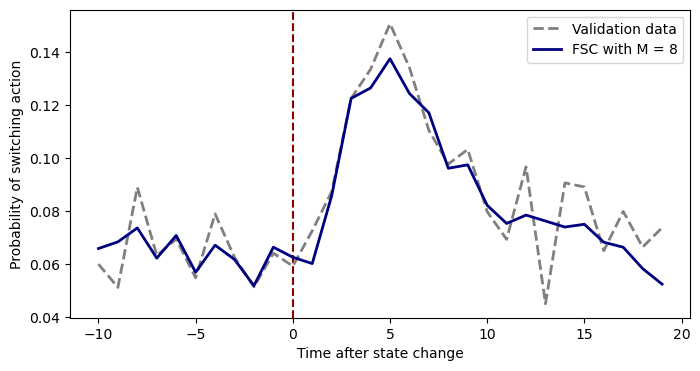

Best loss for M = 9 is 136.60922965358014


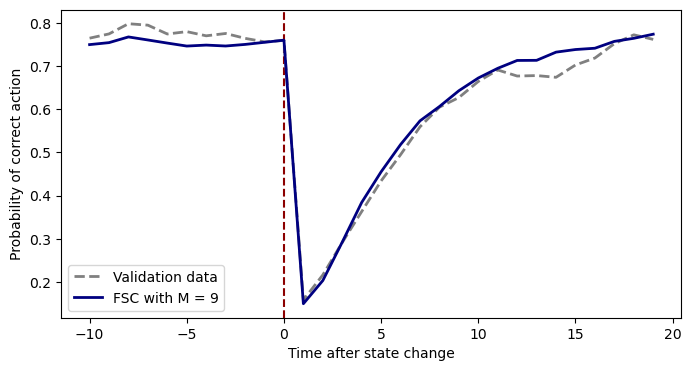

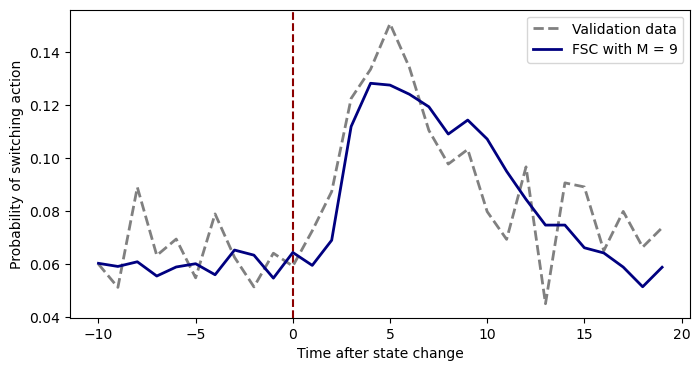

In [43]:
for idx_M in range(3, 8):
    FSC_M = best_FSC_M_list[idx_M]
    MemSpace_M = MemSpaces_list[idx_M]

    print("Best loss for M =", FSC_M.M, "is", FSC_M.best_loss)

    generated_trajectories_M = FSC_M.generate_trajectories(environment_model = env,
                                                            NSteps = np.max(np.concatenate(durations_train + durations_val)),
                                                            NTraj = len(initial_states_data_dict),
                                                            initial_states = initial_states_data_dict,
                                                            obs_from_act = True)

    for idx_trj, dur in enumerate(np.concatenate(durations_train + durations_val)):
        for key in generated_trajectories_M[idx_trj].keys():
            generated_trajectories_M[idx_trj][key] = generated_trajectories_M[idx_trj][key][:dur]

    idx_start = -10
    idx_end = 20
    shifts_time = np.arange(idx_start, idx_end)

    probs_correct_gen_M, probs_switch_gen_M = compute_shift_observables_from_trjs(generated_trajectories_M,
                                                                                    idx_start=idx_start,
                                                                                    idx_end=idx_end)

    fig, ax = plt.subplots(figsize = (8, 4))
    ax.plot(shifts_time, probs_correct_data_val.mean(axis = 0), c = "gray", lw = 2, ls = "--", label = "Validation data")
    ax.plot(shifts_time, probs_correct_gen_M, c = "navy", lw = 2, label = "FSC with M = " + str(FSC_M.M))
    ax.set_xlabel("Time after state change")
    ax.set_ylabel("Probability of correct action")
    ax.axvline(0, ls = "--", c = "darkred", zorder = -1)
    plt.legend()
    plt.show()

    fig, ax = plt.subplots(figsize = (8, 4))
    ax.plot(shifts_time, probs_switch_data_val.mean(axis = 0), c = "gray", lw = 2, ls = "--", label = "Validation data")
    ax.plot(shifts_time, probs_switch_gen_M, c = "navy", lw = 2, label = "FSC with M = " + str(FSC_M.M))
    ax.set_xlabel("Time after state change")
    ax.set_ylabel("Probability of switching action")
    ax.axvline(0, ls = "--", c = "darkred", zorder = -1)
    plt.legend()
    plt.show()